# Knowledge Graph from a LIS Journal Dataset (Google Colab)

Pipeline (matches your four stages):

| Part | Stage |
|---|---|
| **1** | ML/AI semantic extraction – corpus preparation & NLP model framework |
| **2** | Entity normalisation, author disambiguation & NER |
| **3** | Relation extraction & entity linking |
| **4** | KG population, validation & insight generation (+ search / discovery tools) |

**Before you start:** `Runtime ▸ Change runtime type ▸ T4 GPU` (embeddings are ~10x faster).
**Dry run first:** set `SAMPLE_N = 2000` in the config cell, run everything, then set it to `None` for the full 27,825 rows.

Your file has 13 columns: `Cites, Authors, Title, Year, Source, Publisher, Place, Country, ArticleURL, DOI, ISSN, Keywords, Abstract`.
Data-quality issues found in it (handled in Part 1): ~1/3 of "Abstract" cells are just the title, HTML entities (`&amp,`), 75 duplicate DOIs,
inconsistent country names (England / United Kingdom / "United State of america" ...), and authors written mostly as initials (`K. Kandhasamy`).

## Part 0 – Setup

In [ ]:
# 0.1 Install dependencies (≈2 min). If Colab asks to restart the runtime, restart and re-run from 0.2.
!pip -q install spacy sentence-transformers rapidfuzz unidecode pyvis rdflib openpyxl networkx scikit-learn requests
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 98.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 30.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# 0.2 Imports + configuration
import os, re, json, html, math, time, random, unicodedata, itertools, warnings, pickle
from collections import Counter, defaultdict
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from rapidfuzz import fuzz, process
from unidecode import unidecode
from IPython.display import display, HTML
warnings.filterwarnings("ignore")

CFG = dict(
    DATA_PATH   = "/content/kg_dataset.xlsx",
    OUT_DIR     = "/content/kg_output",       # tip: point to /content/drive/MyDrive/... to persist
    SAMPLE_N    = None,                       # e.g. 2000 for a quick dry run
    SEED        = 42,
    EMB_MODEL   = "sentence-transformers/all-MiniLM-L6-v2",
    SPACY_MODEL = "en_core_web_sm",           # use "en_core_web_trf" for higher NER accuracy (slow, GPU)
    MIN_PHRASE_DF = 2,                        # candidate noun phrases must occur in >= 2 papers
    N_KEYPHRASES  = 8,                        # keyphrases per paper (MMR)
    N_TOPICS      = 30,
    CONCEPT_MERGE_COS  = 0.92, CONCEPT_MERGE_FUZZ = 88,
    # author disambiguation thresholds (see 2.4) - tune using the audit file from Part 4
    T_FULL = 0.50, T_PREFIX = 0.35, T_INIT = 0.55, T_INIT_MARGIN = 0.10, T_INVERT = 0.40,
    MIN_REL_SUPPORT = 2,                      # concept->concept relations must appear in >= 2 papers
    HUB_FRAC = 0.05,                          # concepts in >5% of papers are "hubs" (excluded from co-occurrence)
    WD_TOP_CONCEPTS = 300, WD_TOP_ENTITIES = 200,  # Wikidata linking budget
    CONTACT_EMAIL = "your.email@example.com", # used for polite OpenAlex / Wikidata API calls
    OPENALEX_MAX_DOIS = 2000,                 # optional enrichment in 2.7
)
random.seed(CFG["SEED"]); np.random.seed(CFG["SEED"])
OUT = CFG["OUT_DIR"]; os.makedirs(OUT, exist_ok=True)

def save_pkl(obj, name):
    with open(os.path.join(OUT, name), "wb") as f: pickle.dump(obj, f)
def load_pkl(name):
    p = os.path.join(OUT, name)
    return pickle.load(open(p, "rb")) if os.path.exists(p) else None

In [ ]:
# 0.3 Shared helper functions
def norm_phrase(s):
    """lowercase, ASCII-fold, keep letters/digits/hyphen, collapse spaces"""
    s = unidecode(html.unescape(str(s))).lower()
    s = re.sub(r"[^a-z0-9\-+#&/ ]", " ", s)
    return re.sub(r"\s+", " ", s).strip(" -/&")

def key(s):
    return re.sub(r"[^a-z0-9]+", " ", str(s).lower()).strip()

class UF:
    """union-find over hashable items"""
    def __init__(self): self.p = {}
    def find(self, x):
        self.p.setdefault(x, x)
        while self.p[x] != x:
            self.p[x] = self.p[self.p[x]]; x = self.p[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb: self.p[rb] = ra

def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k / n; d = 1 + z*z/n
    c = (p + z*z/(2*n)) / d; h = z*math.sqrt(p*(1-p)/n + z*z/(4*n*n)) / d
    return (round(c-h, 3), round(c+h, 3))

digits = lambda s: tuple(re.findall(r"\d+", s))

In [ ]:
# 0.4 Upload the dataset (skip if the file is already at DATA_PATH)
if not os.path.exists(CFG["DATA_PATH"]):
    from google.colab import files
    up = files.upload()                       # choose kg_dataset.xlsx
    # Or from Google Drive:
    # from google.colab import drive; drive.mount('/content/drive')
    # CFG["DATA_PATH"] = "/content/drive/MyDrive/kg_dataset.xlsx"
print("Found:", os.path.exists(CFG["DATA_PATH"]))

Saving kg_dataset.xlsx to kg_dataset.xlsx
Found: True


## Part 1 – Corpus preparation & NLP/ML model framework
1.1 load/audit → 1.2 clean, de-duplicate, canonicalise → 1.3 load models (sentence-transformer + spaCy with a LIS entity ruler) →
1.4 document embeddings → 1.5 one spaCy pass (NER + noun-phrase candidates, parsed docs saved for relation extraction) →
1.6 embedding-based keyphrase extraction (MMR) → 1.7 semantic topics.

In [ ]:
# 1.1 Load & audit
raw = pd.read_excel(CFG["DATA_PATH"])
raw.columns = [c.strip() for c in raw.columns]
print(raw.shape)
display(raw.head(3))
print(raw.isna().sum())

(27825, 13)


,Cites,Authors,Title,Year,Source,Publisher,Place,Country,ArticleURL,DOI,ISSN,Keywords,Abstract
0,18,Patit Paban Santra; Debasis Majhi,Scholarly Communication and Machine-Generated ...,2023,Journal of Information and Knowledge,Sarada Ranganathan Endowment for Library Scien...,Bangalore,India,https://doi.org/10.17821/srels/2023/v60i3/171028,10.17821/srels/2023/v60i3/171028,2583-9314,language model;AI model; AI writing; AI writin...,This study utilizes GPT (Generative Pre-Traine...
1,8,Bolaji David Oladokun; Joel Eleojo Aruwa; Gabr...,Misinformation and Disinformation in the Era o...,2024,Journal of Information and Knowledge,Sarada Ranganathan Endowment for Library Scien...,Bangalore,India,https://doi.org/10.17821/srels/2024/v61i1/171266,10.17821/srels/2024/v61i1/171266,2583-9314,Fact-Checking Skills; Misinformation; Social M...,The paper explores the need for fact-checking ...
2,8,Manoj Kumar Verma; Mayank Yuvaraj,AI-Based Literature Reviews: A Topic Modeling ...,2023,Journal of Information and Knowledge,Sarada Ranganathan Endowment for Library Scien...,Bangalore,India,https://doi.org/10.17821/srels/2023/v60i2/170967,10.17821/srels/2023/v60i2/170967,2583-9314,Topic Modelling; Conducting Literature Reviews...,The purpose of this paper is to highlight the ...


Cites          0
Authors        0
Title          0
Year           0
Source         0
Publisher      0
Place          0
Country        0
ArticleURL     2
DOI           66
ISSN           0
Keywords       4
Abstract      91
dtype: int64


Removed 76 duplicate records -> 27749 papers
Papers with a real abstract: 17716 (64%)
Journals: 100 | Publishers: 32 | Countries: 11
{'United Kingdom': 13530, 'United States': 4903, 'Netherlands': 4411, 'Germany': 1840, 'India': 1326, 'Iran': 831, 'Sweden': 486, 'Canada': 201, 'Singapore': 123, 'Australia': 75, 'South Korea': 23}


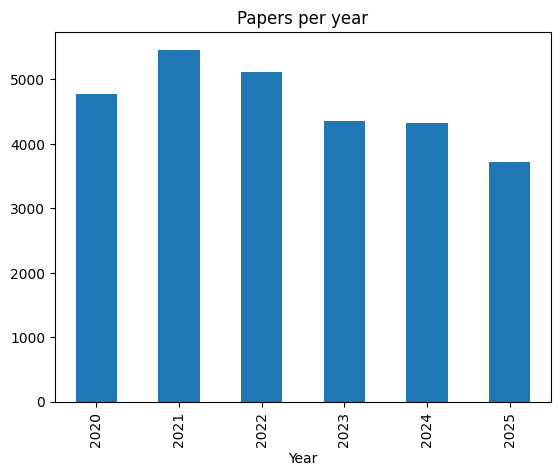

In [ ]:
# 1.2 Clean, de-duplicate, canonicalise
def clean_text(s):
    if pd.isna(s): return ""
    s = str(s).replace("&amp,", "&")                      # broken entity seen in the data
    s = html.unescape(s)
    s = re.sub(r"<[^>]+>", " ", s)
    s = unicodedata.normalize("NFKC", s)
    s = re.sub(r"^\s*abstract\s*[:.\-–]?\s*", "", s, flags=re.I)
    s = re.sub(r"\s*(©|\(c\))\s*\d{4}.{0,200}$", "", s, flags=re.I)   # trailing copyright line
    return re.sub(r"\s+", " ", s).strip()

def norm_doi(d):
    if pd.isna(d): return None
    d = re.sub(r"^(https?://(dx\.)?doi\.org/|doi:\s*)", "", str(d).strip().lower())
    return d or None

def split_list(s, sep=";"):
    if pd.isna(s): return []
    out, seen = [], set()
    for x in str(s).split(sep):
        x = re.sub(r"\s+", " ", clean_text(x)).strip(" .,")
        if x and x.lower() not in seen: seen.add(x.lower()); out.append(x)
    return out

def canon_by_freq(s):
    """merge case/punctuation variants; keep the most frequent surface form"""
    s = s.fillna("").astype(str).str.strip()
    k = s.map(key)
    best = s.groupby(k).agg(lambda x: x.value_counts().idxmax())
    return k.map(best)

COUNTRY_MAP = {"uk": "United Kingdom", "england": "United Kingdom", "great britain": "United Kingdom",
               "united kingdom": "United Kingdom", "usa": "United States", "us": "United States",
               "america": "United States", "united states": "United States",
               "united states of america": "United States", "united state of america": "United States",
               "united state": "United States"}

df = raw.copy()
df["Title"]        = df["Title"].map(clean_text)
df["Abstract_raw"] = df["Abstract"].map(clean_text)
df["doi"]          = df["DOI"].map(norm_doi)
df["title_key"]    = df["Title"].map(key)

# ~1/3 of 'Abstract' cells are only the title (or a fragment) -> treat as missing
def real_abstract(title, ab):
    if not ab or len(ab.split()) < 40: return False
    return fuzz.ratio(key(title), key(ab)) < 90
df["has_abstract"] = [real_abstract(t, a) for t, a in zip(df.Title, df.Abstract_raw)]
df["Abstract"] = np.where(df.has_abstract, df.Abstract_raw, "")

# de-duplicate: DOI first, then (title, year, source)
n0 = len(df)
df = df.sort_values(["has_abstract", "Cites"], ascending=False)
has_doi = df.doi.notna()
df = pd.concat([df[has_doi].drop_duplicates("doi"), df[~has_doi]])
df = df.drop_duplicates(["title_key", "Year", "Source"]).sort_index().reset_index(drop=True)
print(f"Removed {n0-len(df)} duplicate records -> {len(df)} papers")

for c in ["Source", "Publisher", "Place"]: df[c] = canon_by_freq(df[c])
df["Country"] = df["Country"].fillna("").str.strip().map(lambda c: COUNTRY_MAP.get(c.lower(), c))
df["author_list"]  = df["Authors"].map(split_list)
df["keyword_list"] = df["Keywords"].map(split_list)

if CFG["SAMPLE_N"]:
    df = df.sample(CFG["SAMPLE_N"], random_state=CFG["SEED"]).reset_index(drop=True)
df["doc_id"] = ["P%06d" % i for i in range(len(df))]
df["text"] = np.where(df.has_abstract, df.Title.str.rstrip(".") + ". " + df.Abstract, df.Title)

print("Papers with a real abstract:", int(df.has_abstract.sum()), f"({df.has_abstract.mean():.0%})")
print("Journals:", df.Source.nunique(), "| Publishers:", df.Publisher.nunique(), "| Countries:", df.Country.nunique())
print(df.Country.value_counts().to_dict())
df.groupby("Year").size().plot(kind="bar", title="Papers per year"); plt.show()

In [ ]:
# 1.3 Model framework: sentence-transformer embedder + spaCy pipeline with a LIS-specific EntityRuler
import torch, spacy
from sentence_transformers import SentenceTransformer, util
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
embedder = SentenceTransformer(CFG["EMB_MODEL"], device=DEVICE); embedder.max_seq_length = 256

nlp = spacy.load(CFG["SPACY_MODEL"]); nlp.max_length = 2_000_000

# Domain gazetteer: extend freely with your own terms (these override statistical NER)
LIS_TERMS = {
 "TECH": ["bert","gpt","chatgpt","large language model","language model","llm","word2vec","transformer","convolutional neural network",
          "recurrent neural network","lstm","random forest","support vector machine","svm","neural network","deep learning model",
          "knowledge graph","ontology","linked data","semantic web","rdf","sparql","blockchain","rfid","koha","dspace","eprints",
          "vosviewer","citespace","bibliometrix","python","tableau","chatbot","generative ai","recommender system","search engine","wikipedia","orcid"],
 "METHOD": ["bibliometric analysis","systematic literature review","systematic review","scoping review","content analysis","thematic analysis",
            "topic modelling","topic modeling","sentiment analysis","citation analysis","co-citation analysis","bibliographic coupling",
            "co-word analysis","social network analysis","text mining","machine learning","deep learning","natural language processing",
            "meta-analysis","case study","delphi method","structural equation modelling","regression analysis","survey research","altmetrics"],
 "PRACTICE": ["open access","open science","open data","digital preservation","information literacy","reference service","institutional repository",
              "digital library","metadata","cataloguing","research data management","fair principles","peer review","knowledge management",
              "scholarly communication","information retrieval","digital humanities","library automation","academic library"],
 "DATASET_SRC": ["scopus","web of science","google scholar","openalex","pubmed","lens.org","crossref","microsoft academic","twitter","youtube"],
}
ruler = nlp.add_pipe("entity_ruler", after="ner", config={"phrase_matcher_attr": "LOWER", "overwrite_ents": True})
ruler.add_patterns([{"label": lab, "pattern": t} for lab, ts in LIS_TERMS.items() for t in ts])
print(nlp.pipe_names)

Device: cpu


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner', 'entity_ruler']


In [9]:
# 1.4 Document embeddings (title + abstract) - cached to disk
emb_path = os.path.join(OUT, f"doc_emb_{len(df)}.npy")
if os.path.exists(emb_path):
    doc_emb = np.load(emb_path)
else:
    doc_emb = embedder.encode(df.text.tolist(), batch_size=128, show_progress_bar=True,
                              normalize_embeddings=True, convert_to_numpy=True).astype("float32")
    np.save(emb_path, doc_emb)
print(doc_emb.shape)

(27749, 384)


In [10]:
# 1.5 One spaCy pass: NER + noun-phrase candidates. Parsed docs are saved (DocBin) and re-used for relation extraction in Part 3.
from spacy.tokens import DocBin
KEEP_ENT = {"ORG","GPE","LOC","NORP","EVENT","LAW","PRODUCT","WORK_OF_ART","FAC","PERSON","TECH","METHOD","PRACTICE","DATASET_SRC"}
EDGE_POS = {"DET","PRON","NUM","PUNCT","ADP","CCONJ","SCONJ","PART","AUX","SYM"}
LEAD_DROP = {"such","various","several","many","other","novel","new","proposed","existing","different","main","key","recent",
             "current","significant","important","effective","efficient","better","best","high","low","large","small"}
GENERIC_CHUNKS = set("""study paper research result results approach analysis method methods model models work article purpose finding findings
implication implications way number case author authors literature aim objective objectives problem problems issue issues performance
effect effects impact role factor factors type types example examples order terms time level levels one two three part parts review
paper's study's""".split())

def chunk_candidates(doc):
    out = []
    for nc in doc.noun_chunks:
        toks = list(nc)
        while toks and (toks[0].pos_ in EDGE_POS or toks[0].lower_ in LEAD_DROP): toks = toks[1:]
        while toks and (toks[-1].pos_ in EDGE_POS): toks = toks[:-1]
        if not toks or len(toks) > 4: continue
        p = norm_phrase(" ".join(t.text for t in toks))
        if len(p) < 3 or p in GENERIC_CHUNKS or not re.search(r"[a-z]", p): continue
        if len(toks) == 1 and toks[0].pos_ not in ("NOUN", "PROPN"): continue
        out.append(p)
    return out

db_path = os.path.join(OUT, f"docs_{len(df)}.spacy"); ner_path = f"ner_chunks_{len(df)}.pkl"
cached = load_pkl(ner_path)
if cached and os.path.exists(db_path):
    doc_ents, doc_chunks = cached
else:
    doc_ents, doc_chunks = [], []
    docbin = DocBin(attrs=["LEMMA","POS","TAG","DEP","HEAD","ENT_IOB","ENT_TYPE"], store_user_data=False)
    for doc in tqdm(nlp.pipe(df.text.tolist(), batch_size=64, n_process=2), total=len(df)):
        docbin.add(doc)
        doc_ents.append([(e.text, e.label_) for e in doc.ents if e.label_ in KEEP_ENT])
        doc_chunks.append(list(dict.fromkeys(chunk_candidates(doc))))
    docbin.to_disk(db_path); save_pkl((doc_ents, doc_chunks), ner_path)
print("Example entities:", doc_ents[0][:8]); print("Example phrases:", doc_chunks[0][:10])

  0%|          | 0/27749 [00:00<?, ?it/s]

Example entities: [('Scholarly Communication', 'PRACTICE'), ('Plagiarism Detection', 'GPE'), ('GPT', 'TECH'), ('Transformer', 'TECH'), ('language model', 'TECH'), ('AI', 'ORG'), ('AI', 'GPE'), ('AI', 'GPE')]
Example phrases: ['plagiarism detection', 'gpt', 'set', 'academic writing samples', 'themes', 'experiential sessions', 'ltc', 'samples', 'words', 'conventional plagiarism detection tools']


In [11]:
# 1.6 Embedding-based keyphrase extraction (KeyBERT-style, with Maximal Marginal Relevance for diversity)
kw_norm = [[p for p in (norm_phrase(k) for k in kws) if p] for kws in df.keyword_list]
dfc = Counter(p for chunks in doc_chunks for p in set(chunks))                 # phrase document-frequency
cand_vocab = {p for p, c in dfc.items() if c >= CFG["MIN_PHRASE_DF"]}
phrase_vocab = sorted(cand_vocab | {k for kws in kw_norm for k in kws})
phrase_idx = {p: i for i, p in enumerate(phrase_vocab)}
print("Phrase vocabulary:", len(phrase_vocab))

pe_path = os.path.join(OUT, f"phrase_emb_{len(phrase_vocab)}.npy")
if os.path.exists(pe_path): phrase_emb = np.load(pe_path)
else:
    phrase_emb = embedder.encode(phrase_vocab, batch_size=256, normalize_embeddings=True, show_progress_bar=True).astype("float32")
    np.save(pe_path, phrase_emb)

def mmr(doc_vec, E, top_k=8, diversity=0.5):
    sim_d = E @ doc_vec; sim_c = E @ E.T
    sel = [int(np.argmax(sim_d))]
    while len(sel) < min(top_k, len(E)):
        rest = [i for i in range(len(E)) if i not in sel]
        sc = [(1-diversity)*sim_d[i] - diversity*sim_c[i, sel].max() for i in rest]
        sel.append(rest[int(np.argmax(sc))])
    return sel, sim_d

doc_keyphrases = []
for i, chunks in enumerate(tqdm(doc_chunks)):
    cands = [p for p in chunks if p in cand_vocab]
    if not cands: doc_keyphrases.append([]); continue
    E = phrase_emb[[phrase_idx[p] for p in cands]]
    sel, sim_d = mmr(doc_emb[i], E, CFG["N_KEYPHRASES"])
    doc_keyphrases.append([(cands[j], float(sim_d[j])) for j in sel])
print(df.Title[0], "->", doc_keyphrases[0])

Phrase vocabulary: 75345


Batches:   0%|          | 0/295 [00:00<?, ?it/s]

  0%|          | 0/27749 [00:00<?, ?it/s]

Scholarly Communication and Machine-Generated Text: Is it Finally AI vs AI in Plagiarism Detection? -> [('plagiarism detection', 0.6440982222557068), ('ai - generated text', 0.583358108997345), ('gpt', 0.15569716691970825), ('scholarly communication process', 0.3364231288433075), ('era', 0.0820210874080658), ('specific characteristics', 0.018318919464945793), ('potential solution', -0.035677600651979446), ('words', 0.15304067730903625)]


In [12]:
# 1.7 Semantic topics: KMeans on embeddings, labelled with class-based TF-IDF terms
from sklearn.cluster import MiniBatchKMeans
from sklearn.feature_extraction.text import TfidfVectorizer
K = min(CFG["N_TOPICS"], max(2, len(df)//50))
km = MiniBatchKMeans(n_clusters=K, random_state=CFG["SEED"], batch_size=2048, n_init=3).fit(doc_emb)
df["topic_id"] = km.labels_
cdocs = df.groupby("topic_id").text.apply(" ".join)
tv = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2, max_df=0.5, max_features=100000)
X = tv.fit_transform(cdocs.values); terms = np.array(tv.get_feature_names_out())
topics = pd.DataFrame({"topic_id": cdocs.index,
        "label": [", ".join(terms[np.argsort(-X[i].toarray()[0])[:4]]) for i in range(X.shape[0])],
        "n_papers": df.topic_id.value_counts().sort_index().values})
display(topics.sort_values("n_papers", ascending=False).head(15))

,topic_id,label,n_papers
6,6,"library websites, libraries nigeria, resources...",1372
10,10,"convolutional, convolutional neural, intrusion...",1304
27,27,"digital preservation, records management, reco...",1291
8,8,"intention use, continuance, smes, esm",1284
13,13,"wikidata, library instruction, 2023 https, lib...",1190
5,5,"literacy skills, data literacy, moocs, mil",1188
3,3,"research productivity, scientometric, predator...",1151
28,28,"librarianship, academic librarians, burnout, m...",1124
7,7,"feature selection, eeg, tumor, image processing",1122
25,25,"ogd, km, gig, digital government",1110


## Part 2 – Entity normalisation, author disambiguation & NER
2.1 acronym mining + synonym dictionary → 2.2 concept clustering (exact / fuzzy / embedding) → 2.3 concept typing (embedding prototypes + rules) →
2.4–2.5 author disambiguation with constraints and evidence scoring → 2.6 NER normalisation → 2.7 optional OpenAlex validation.

In [13]:
# 2.1 Acronym mining from the corpus ("natural language processing (NLP)") + seed synonyms
FUNC = {"of","and","for","the","in","on","to","from","with","a","an","&"}
ACR_RE = re.compile(r"\b((?:[A-Za-z][\w\-]*\s+){1,7}[A-Za-z][\w\-]*)\s*\(([A-Z][A-Za-z0-9]{1,9}s?)\)")

def acronym_pairs(text):
    out = []
    for m in ACR_RE.finditer(text):
        words, acr = m.group(1).split(), m.group(2)
        if acr.endswith("s") and acr[:-1].isupper(): acr = acr[:-1]
        letters = re.sub(r"[^a-z0-9]", "", acr.lower())
        if len(letters) < 2: continue
        for w in range(len(letters), len(letters) + 4):
            win = words[-w:]
            if len(win) < w: break
            ini = "".join(x[0].lower() for x in win if x.lower() not in FUNC)
            if ini == letters and win[0].lower() not in FUNC:
                out.append((letters, norm_phrase(" ".join(win)))); break
    return out

acr_counter = defaultdict(Counter)
for t in tqdm(df.text):
    for a, l in acronym_pairs(t): acr_counter[a][l] += 1
ACR2LONG = {}
for a, c in acr_counter.items():
    long_, n = c.most_common(1)[0]
    if n >= 3 and n / sum(c.values()) >= 0.7: ACR2LONG[a] = long_      # frequent AND unambiguous only

SEED_SYN = {"ai": "artificial intelligence", "ml": "machine learning", "dl": "deep learning", "nlp": "natural language processing",
            "llm": "large language model", "llms": "large language model", "lis": "library and information science",
            "ict": "information and communication technology", "kg": "knowledge graph", "covid19": "covid-19", "covid 19": "covid-19",
            "coronavirus disease 2019": "covid-19", "sars-cov-2": "covid-19", "oa": "open access", "rdm": "research data management"}
SYN = {**{a: l for a, l in ACR2LONG.items()}, **SEED_SYN}
print(len(ACR2LONG), "mined acronyms, e.g.", list(ACR2LONG.items())[:8])

  0%|          | 0/27749 [00:00<?, ?it/s]

285 mined acronyms, e.g. [('osf', 'open science framework'), ('lod', 'linked open data'), ('rag', 'retrieval augmented generation'), ('llm', 'large language models'), ('ai', 'artificial intelligence'), ('sdg', 'sustainable development goals'), ('oer', 'open educational resources'), ('nlp', 'natural language processing')]


In [14]:
# 2.2 Concept normalisation: merge variants (synonyms/acronyms, punctuation, plural/spelling, embedding+fuzzy) into canonical concepts
kw_counter = Counter(k for kws in kw_norm for k in set(kws))
phrase_freq = {p: kw_counter.get(p, 0) + dfc.get(p, 0) for p in phrase_vocab}
uf_c = UF()
for p in phrase_vocab: uf_c.find(p)
merge_log = []

for p in phrase_vocab:                                  # (a) dictionary / acronyms
    tgt = SYN.get(p)
    if tgt and tgt in phrase_idx and tgt != p: uf_c.union(tgt, p); merge_log.append((p, tgt, "synonym", 1.0))

sq = defaultdict(list)                                  # (b) spacing/hyphen variants: "e-learning" = "elearning"
for p in phrase_vocab: sq[re.sub(r"[^a-z0-9]", "", p)].append(p)
for g in sq.values():
    for x in g[1:]: uf_c.union(g[0], x); merge_log.append((x, g[0], "squash", 1.0))

E = torch.from_numpy(phrase_emb).to(DEVICE)             # (c) semantic neighbours + string similarity guard
hits = util.semantic_search(E, E, top_k=6, query_chunk_size=2000, corpus_chunk_size=50000)
for i, hs in enumerate(tqdm(hits)):
    a = phrase_vocab[i]
    for h in hs:
        j = h["corpus_id"]
        if j <= i or h["score"] < CFG["CONCEPT_MERGE_COS"]: continue
        b = phrase_vocab[j]
        if len(a) < 8 or len(b) < 8 or digits(a) != digits(b): continue
        fz = fuzz.token_sort_ratio(a, b)
        if fz >= CFG["CONCEPT_MERGE_FUZZ"] and (fz >= 90 or max(len(a), len(b)) >= 14):
            uf_c.union(a, b); merge_log.append((a, b, "semantic+fuzzy", round(h["score"], 3)))
del E

case_counter = defaultdict(Counter)
for kws in df.keyword_list:
    for k in kws: case_counter[norm_phrase(k)][k] += 1
groups = defaultdict(list)
for p in phrase_vocab: groups[uf_c.find(p)].append(p)
rows = []
for mem in groups.values():
    canon = max(mem, key=lambda p: (phrase_freq[p], -len(p)))
    rows.append(dict(canon=canon, label=(case_counter[canon].most_common(1)[0][0] if canon in case_counter else canon),
                     freq=sum(phrase_freq[p] for p in mem), members=mem, n_variants=len(mem)))
concepts = pd.DataFrame(rows).sort_values("freq", ascending=False).reset_index(drop=True)
concepts["concept_id"] = ["C%05d" % i for i in range(len(concepts))]
concepts["canon_idx"] = concepts.canon.map(phrase_idx)
concept_of = {p: cid for cid, mem in zip(concepts.concept_id, concepts.members) for p in mem}
concept_vec = phrase_emb[concepts.canon_idx.values]       # one embedding per concept
cid2row = {c: i for i, c in enumerate(concepts.concept_id)}
concept_merge_audit = pd.DataFrame(merge_log, columns=["variant", "merged_into", "rule", "score"])
print(f"{len(phrase_vocab)} phrases -> {len(concepts)} concepts | largest clusters:")
display(concepts.sort_values("n_variants", ascending=False)[["label", "n_variants", "freq"]].head(10))

  0%|          | 0/75345 [00:00<?, ?it/s]

75345 phrases -> 69634 concepts | largest clusters:


,label,n_variants,freq
2417,using partial least squares structural equatio...,17,35
762,information - seeking behavior,11,123
3031,knowledge - sharing behavior,9,27
163,ICT,8,448
5248,live streaming commerce,8,15
3578,librarians roles,7,23
710,Technological advancements,7,132
962,f1 - score,7,97
2461,student experience,6,35
1312,Knowledge Organization Systems,6,70


In [15]:
# 2.3 Concept typing: rule labels from the EntityRuler win; otherwise nearest embedding prototype (zero-shot, tune examples freely)
TYPE_PROTOS = {
 "Technology":   ["machine learning algorithm","software platform","neural network","database system","blockchain","chatbot","search engine","programming language"],
 "Method":       ["systematic review","bibliometric analysis","survey methodology","content analysis","regression analysis","qualitative interviews","topic modelling","statistical test"],
 "Task":         ["text classification","information retrieval","citation prediction","plagiarism detection","knowledge discovery","question answering","recommendation","named entity recognition"],
 "LIS_Practice": ["open access publishing","digital preservation","information literacy","library services","metadata cataloguing","scholarly communication","research data management","institutional repository"],
 "Data_Resource":["scopus database","web of science","social media data","benchmark dataset","digital collections","text corpus","open data","electronic resources"],
 "Domain_Topic": ["covid-19 pandemic","higher education","healthcare","climate change","tourism","agriculture","public policy","gender and diversity"],
}
proto_vec = {t: embedder.encode(ex, normalize_embeddings=True).mean(0) for t, ex in TYPE_PROTOS.items()}
P = np.vstack([v / np.linalg.norm(v) for v in proto_vec.values()]); ptypes = list(proto_vec)
S = concept_vec @ P.T
concepts["concept_type"] = np.where(S.max(1) >= 0.30, np.array(ptypes)[S.argmax(1)], "Concept")
concepts["type_conf"] = S.max(1).round(3)

CONCEPT_ENT = {"TECH": "Technology", "METHOD": "Method", "PRACTICE": "LIS_Practice", "DATASET_SRC": "Data_Resource"}
rule_votes = defaultdict(Counter)
for ents in doc_ents:
    for text, lab in ents:
        if lab in CONCEPT_ENT:
            cid = concept_of.get(norm_phrase(text))
            if cid: rule_votes[cid][CONCEPT_ENT[lab]] += 1
for cid, c in rule_votes.items():
    i = cid2row[cid]; concepts.at[i, "concept_type"] = c.most_common(1)[0][0]; concepts.at[i, "type_conf"] = 1.0
print(concepts.concept_type.value_counts())

concept_type
Concept          22419
Domain_Topic     15717
LIS_Practice      8625
Method            7667
Technology        6034
Task              5718
Data_Resource     3454
Name: count, dtype: int64


In [16]:
# 2.4 Author disambiguation - parsing + evidence functions
# Dataset facts: no IDs/affiliations; many names are initials ("K. Kandhasamy"); some are single tokens ("Duragappa").
# Strategy: block by surname+first initial -> compatibility of given names -> evidence (shared co-author, same journal, topic similarity)
#           with a hard "cannot-link" rule (two variants on the SAME paper are different people).
PARTICLES = {"van","von","de","der","den","da","di","del","la","le","bin","ibn","al","el","abu","dos","du","ter"}

def parse_author(raw):
    s0 = unidecode(str(raw)).strip()
    if "," in s0:
        last, first = s0.split(",", 1); s0 = f"{first.strip()} {last.strip()}"
    s = re.sub(r"[^A-Za-z.\-' ]", " ", s0).replace(".", ". ").replace("-", " ").replace("'", "")
    parts = s.split()
    all_upper = all(p.rstrip(".").isupper() for p in parts if p.rstrip("."))
    toks = []
    for i, p in enumerate(parts):
        c = p.rstrip(".")
        if not c: continue
        if (not all_upper) and i < len(parts)-1 and c.isupper() and 2 <= len(c) <= 3 and not p.endswith("."):
            toks.extend(list(c.lower()))                       # glued initials "PK Sinha"
        else: toks.append(c.lower())
    if not toks: return dict(norm="", surname="", given=(), kind="none", block="")
    sur = toks.pop()
    while toks and toks[-1] in PARTICLES: sur = toks.pop() + " " + sur
    given = tuple(toks)
    kind = "mono" if not given else ("initial" if len(given[0]) == 1 else "full")
    return dict(norm=" ".join(list(given) + [sur]), surname=sur, given=given, kind=kind,
                block=(sur + "_" + given[0][0]) if given else sur)

def given_compatible(ga, gb):
    for x, y in zip(ga, gb):
        if x == y: continue
        if len(x) == 1 or len(y) == 1:
            if x[0] == y[0]: continue
            return False
        if min(len(x), len(y)) >= 6 and fuzz.ratio(x, y) >= 88: continue   # mohammad / muhammad (NOT zhen / zheng)
        return False
    return True

# mention table
mrows = []
for i, (did, al) in enumerate(zip(df.doc_id, df.author_list)):
    for pos, raw_name in enumerate(al):
        p = parse_author(raw_name)
        if p["norm"]: mrows.append(dict(doc_idx=i, doc_id=did, pos=pos, raw=raw_name, **p))
Mn = pd.DataFrame(mrows)
doc_blocks = Mn.groupby("doc_idx")["block"].agg(set).to_dict()
var_rows = Mn.groupby("norm")["doc_idx"].agg(lambda x: sorted(set(x))).to_dict()
V = Mn.drop_duplicates("norm").set_index("norm")[["surname", "given", "kind", "block"]]
print(f"{len(Mn)} author mentions | {len(V)} distinct normalised name variants | kinds: {V.kind.value_counts().to_dict()}")

_stat = {}
def stats(norms):
    k = tuple(sorted(norms))
    if k in _stat: return _stat[k]
    rws = sorted(set(itertools.chain.from_iterable(var_rows[n] for n in norms)))
    emb = doc_emb[rws].mean(0); emb = emb / (np.linalg.norm(emb) + 1e-9)
    own = {V.at[n, "block"] for n in norms}
    co = set().union(*(doc_blocks[r] for r in rws)) - own
    _stat[k] = dict(rows=set(rws), emb=emb, co=co, src=set(df.Source.iloc[rws]))
    return _stat[k]

def evidence(a, b):
    co  = 1.0 if (a["co"] & b["co"]) else 0.0
    src = len(a["src"] & b["src"]) / max(1, len(a["src"] | b["src"]))
    top = float(a["emb"] @ b["emb"])
    return 0.45*co + 0.15*src + 0.40*max(0.0, top)
cannot_link = lambda a, b: bool(a["rows"] & b["rows"])

81026 author mentions | 52746 distinct normalised name variants | kinds: {'full': 50201, 'initial': 2258, 'mono': 287}


In [17]:
# 2.5 Author disambiguation - clustering, ID assignment, audit tables
uf_a = UF(); author_log = []
for n in V.index: uf_a.find(n)

def run_blocks():
    for blk, g in tqdm(V.groupby("block"), total=V.block.nunique()):
        if len(g) < 2: continue
        full = [n for n in g.index if g.at[n, "kind"] == "full"]
        init = [n for n in g.index if g.at[n, "kind"] == "initial"]
        for a, b in itertools.combinations(full, 2):                      # (i) full-name variants
            if not given_compatible(g.at[a, "given"], g.at[b, "given"]): continue
            sa, sb = stats([a]), stats([b])
            if cannot_link(sa, sb): continue
            sc = evidence(sa, sb); co_ = bool(sa["co"] & sb["co"]); ga, gb = g.at[a, "given"], g.at[b, "given"]
            if min(len(ga[0]), len(gb[0])) >= 6 and fuzz.ratio(a, b) >= 92 and sc >= 0.20: rule = "near-identical"        # long names only
            elif ga[0] == gb[0] and co_ and sc >= CFG["T_PREFIX"]:                  rule = "prefix+coauthor"   # "Manoj K. Verma" ~ "Manoj Verma"
            elif sc >= CFG["T_FULL"]:                                              rule = "evidence"
            else: rule = None
            if rule: uf_a.union(a, b); author_log.append((a, b, rule, round(sc, 3)))
        for u in init:                                                   # (ii) initial-only variants -> best full-name cluster
            clusters = defaultdict(list)
            for n in full:
                if given_compatible(g.at[u, "given"], g.at[n, "given"]): clusters[uf_a.find(n)].append(n)
            if not clusters: continue
            su = stats([u]); scored = []
            for r, members in clusters.items():
                sc_ = stats(members)
                if not cannot_link(su, sc_): scored.append((evidence(su, sc_), r, members))
            scored.sort(reverse=True, key=lambda x: x[0])
            if scored and scored[0][0] >= CFG["T_INIT"] and (len(scored) == 1 or scored[0][0] - scored[1][0] >= CFG["T_INIT_MARGIN"]):
                uf_a.union(scored[0][1], u); author_log.append((u, scored[0][2][0], "initial->full", round(scored[0][0], 3)))
run_blocks()

# (iii) word-order inversions across blocks: "Majhi Debasis" = "Debasis Majhi"
bytok = defaultdict(list)
for n in V.index[V.kind == "full"]:
    t = n.split()
    if len(t) >= 2: bytok[frozenset(t)].append(n)
for grp in bytok.values():
    for a, b in itertools.combinations(grp, 2):
        sa, sb = stats([a]), stats([b])
        if not cannot_link(sa, sb) and evidence(sa, sb) >= CFG["T_INVERT"]:
            uf_a.union(a, b); author_log.append((a, b, "inversion", round(evidence(sa, sb), 3)))

def finalize_authors(extra_pairs=()):
    """build author master + variant->author_id map; extra_pairs = (variantA, variantB) merges from external evidence (e.g. OpenAlex)"""
    for a, b in extra_pairs:
        if a in V.index and b in V.index and not cannot_link(stats([a]), stats([b])): uf_a.union(a, b)
    root = {n: uf_a.find(n) for n in V.index}
    mm = Mn.copy(); mm["root"] = mm.norm.map(root)
    order = mm.groupby("root").doc_idx.nunique().sort_values(ascending=False).index
    rid = {r: "A%05d" % i for i, r in enumerate(order)}
    mm["author_id"] = mm.root.map(rid)
    rows = []
    for aid, g in mm.groupby("author_id"):
        docs = sorted(set(g.doc_idx)); sub = df.iloc[docs]
        cand = g[g.kind == "full"] if (g.kind == "full").any() else g
        name = cand.groupby("raw").size().sort_values(ascending=False).index[0]
        coh = np.nan
        if len(docs) >= 6:
            E_ = doc_emb[docs]; c_ = E_.mean(0); c_ /= np.linalg.norm(c_) + 1e-9; coh = float((E_ @ c_).mean())
        rows.append(dict(author_id=aid, name=name, n_papers=len(docs), first_year=int(sub.Year.min()), last_year=int(sub.Year.max()),
                         total_cites=int(sub.Cites.sum()), n_journals=sub.Source.nunique(), n_variants=g.raw.nunique(),
                         variants=sorted(g.raw.unique()), coherence=coh))
    am = pd.DataFrame(rows).sort_values("n_papers", ascending=False).reset_index(drop=True)
    am["homonym_risk"] = (am.coherence < 0.40) & (am.n_journals >= 3)       # many unrelated topics/journals => maybe 2+ people
    return mm, am

Mn, author_master = finalize_authors()
print(f"{Mn.raw.nunique()} raw name strings -> {Mn.norm.nunique()} normalised variants -> {len(author_master)} authors")
print("Flagged for homonym review:", int(author_master.homonym_risk.sum()))
display(author_master.head(10)[["author_id", "name", "n_papers", "total_cites", "n_variants"]])
author_merge_audit = pd.DataFrame(author_log, columns=["variant_a", "variant_b", "rule", "score"])

  0%|          | 0/37591 [00:00<?, ?it/s]

52901 raw name strings -> 52746 normalised variants -> 52482 authors
Flagged for homonym review: 6


,author_id,name,n_papers,total_cites,n_variants
0,A00000,Dickson K.W. Chiu,55,2167,1
1,A00001,Brady Lund,54,2860,1
2,A00002,Manoj Kumar Verma,53,382,2
3,A00003,Yi Bu,52,1165,1
4,A00004,Khalid Mahmood,46,1548,1
5,A00005,Nosheen Fatima Warraich,46,705,1
6,A00006,Muhammad Rafiq,43,650,1
7,A00007,Mike Thelwall,43,1618,1
8,A00008,Jaime A. Teixeira da Silva,42,848,1
9,A00009,Yogesh K. Dwivedi,41,14051,1


In [18]:
# 2.6 NER normalisation: clean entity strings, cluster spelling variants per label, keep entities seen in >= 2 papers
ENT_TO_TYPE = {"ORG": "Organization", "GPE": "Place", "LOC": "Place", "NORP": "Group", "EVENT": "Event", "LAW": "Law",
               "PRODUCT": "Product", "WORK_OF_ART": "Work", "FAC": "Facility"}      # PERSON mentions are ignored on purpose
erows = []
for i, ents in enumerate(doc_ents):
    for text, lab in ents:
        p = re.sub(r"^(the|a|an)\s+", "", norm_phrase(text))
        if len(p) >= 2 and not p.isdigit(): erows.append((df.doc_id.iat[i], text, lab, p))
ents_df = pd.DataFrame(erows, columns=["doc_id", "surface", "label", "norm"]).drop_duplicates(["doc_id", "label", "norm"])

def fuzzy_cluster(strings, freq, cutoff=92, chunk=2000):
    strings = list(strings); uf = UF()
    for s in strings: uf.find(s)
    for st in range(0, len(strings), chunk):
        sc = process.cdist(strings[st:st+chunk], strings, scorer=fuzz.token_sort_ratio, score_cutoff=cutoff, workers=-1, dtype=np.uint8)
        for a, b in zip(*np.nonzero(sc)):
            if a + st < b: uf.union(strings[a + st], strings[b])
    groups = defaultdict(list)
    for s in strings: groups[uf.find(s)].append(s)
    return {s: max(m, key=lambda x: freq[x]) for m in groups.values() for s in m}

nc = ents_df[ents_df.label.isin(ENT_TO_TYPE)].copy()
canon_map = {}
for lab, g in nc.groupby("label"):
    fr = g.groupby("norm").doc_id.nunique(); fr = fr[fr >= 2]
    if len(fr): canon_map.update({(lab, k): (lab, v) for k, v in fuzzy_cluster(fr.index, fr.to_dict()).items()})
nc["ent_key"] = [canon_map.get((l, n)) for l, n in zip(nc.label, nc.norm)]
nc = nc.dropna(subset=["ent_key"])
ent_nodes = (nc.groupby("ent_key").agg(doc_freq=("doc_id", "nunique"), surface=("surface", lambda x: x.value_counts().index[0])).reset_index()
               .sort_values("doc_freq", ascending=False).reset_index(drop=True))
ent_nodes["entity_id"] = ["E%05d" % i for i in range(len(ent_nodes))]
ent_nodes["label_ner"] = ent_nodes.ent_key.map(lambda k: k[0]); ent_nodes["etype"] = ent_nodes.label_ner.map(ENT_TO_TYPE)
ent_nodes["name"] = ent_nodes.apply(lambda r: r.surface if len(r.surface) > 2 else r.ent_key[1], axis=1)
nc["entity_id"] = nc.ent_key.map(dict(zip(ent_nodes.ent_key, ent_nodes.entity_id)))
print(len(ent_nodes), "normalised entities"); display(ent_nodes.head(12)[["entity_id", "name", "etype", "doc_freq"]])

5070 normalised entities


,entity_id,name,etype,doc_freq
0,E00000,COVID-19,Organization,1020
1,E00001,ai,Place,793
2,E00002,India,Place,755
3,E00003,China,Place,727
4,E00004,the United States,Place,480
5,E00005,Chinese,Group,463
6,E00006,Indian,Group,371
7,E00007,Digital,Organization,367
8,E00008,USA,Place,336
9,E00009,ai,Organization,324


In [19]:
# 2.7 (OPTIONAL) External validation of author identity with OpenAlex: ORCID/OpenAlex IDs merge name variants and add institutions.
# Uses the free API (polite pool via mailto). ~10 requests/s; results are cached so you can resume. Skip if offline.
import requests, concurrent.futures as cf
OA_CACHE = os.path.join(OUT, "openalex_cache.json")
oa_cache = json.load(open(OA_CACHE)) if os.path.exists(OA_CACHE) else {}

def fetch_openalex(doi):
    if doi in oa_cache: return oa_cache[doi]
    try:
        r = requests.get(f"https://api.openalex.org/works/https://doi.org/{doi}",
                         params={"mailto": CFG["CONTACT_EMAIL"], "select": "id,authorships"}, timeout=20)
        oa_cache[doi] = r.json().get("authorships", []) if r.status_code == 200 else []
    except Exception: return None
    return oa_cache[doi]

dois = df.doi.dropna().head(CFG["OPENALEX_MAX_DOIS"]).tolist()
todo = [d for d in dois if d not in oa_cache]
with cf.ThreadPoolExecutor(5) as ex: list(tqdm(ex.map(fetch_openalex, todo), total=len(todo)))
json.dump(oa_cache, open(OA_CACHE, "w"))

# match OpenAlex authorships to our name variants within each paper
oa_author_info, oa_variant = {}, defaultdict(set)         # oa_id -> info ; oa_id -> {our variants}
doi2idx = {d: i for i, d in enumerate(df.doi) if d}
for doi, auths in oa_cache.items():
    if doi not in doi2idx or not auths: continue
    ours = Mn[Mn.doc_idx == doi2idx[doi]]
    for a in auths:
        au = a.get("author") or {}; nm = au.get("display_name") or a.get("raw_author_name")
        if not au.get("id") or not nm: continue
        pn = parse_author(nm)["norm"]
        if not len(ours): continue
        sc = ours.norm.map(lambda x: fuzz.token_sort_ratio(x, pn))
        if sc.max() >= 85:
            oa_variant[au["id"]].add(ours.norm.loc[sc.idxmax()])
            info = oa_author_info.setdefault(au["id"], dict(name=nm, orcid=au.get("orcid"), institutions={}))
            for ins in a.get("institutions", []): info["institutions"][ins.get("id")] = (ins.get("display_name"), ins.get("country_code"))
extra = [(v[0], x) for v in map(list, oa_variant.values()) for x in v[1:]]
print(len(oa_author_info), "OpenAlex authors matched;", len(extra), "extra variant merges proposed")
Mn, author_master = finalize_authors(extra)
print("Authors after OpenAlex merge:", len(author_master))

  0%|          | 0/2000 [00:00<?, ?it/s]

529 OpenAlex authors matched; 0 extra variant merges proposed
Authors after OpenAlex merge: 52482


## Part 3 – Relation extraction & entity linking
3.1 paper→concept links (author keywords + ML keyphrases + rule entities) → 3.2 dependency-based relation extraction (verb lexicon → controlled relation types, with evidence sentences) →
3.3 aggregation/filtering → 3.4 linking to Wikidata with embedding-based disambiguation.

*Optional upgrade:* a neural relation-extraction model such as `Babelscape/rebel-large` can be run on a sample of abstracts and its triples mapped through `link_batch()` below.

In [20]:
# 3.1 Paper -> concept links + generic entity->concept linker (exact -> fuzzy -> semantic)
STOP_NORMS = set("""study research paper article analysis review approach method methods result results work information data case
purpose finding findings literature author authors their this these those our its such other new""".split())
STOP_IDS = {concept_of[p] for p in STOP_NORMS if p in concept_of}

concept_norms = list(concept_of.keys())
def link_batch(surfaces, fuzzy_cut=92, sem_cut=0.90):
    """map free-text surfaces to concept_ids. returns {surface: (concept_id|None, score, method)}"""
    out, pend = {}, []
    for s in set(surfaces):
        p = SYN.get(norm_phrase(s), norm_phrase(s))
        if p in concept_of: out[s] = (concept_of[p], 1.0, "exact")
        else: pend.append((s, p))
    still = []
    for s, p in pend:
        m = process.extractOne(p, concept_norms, scorer=fuzz.token_sort_ratio, score_cutoff=fuzzy_cut) if len(p) >= 6 else None
        if m and digits(m[0]) == digits(p): out[s] = (concept_of[m[0]], m[1] / 100, "fuzzy")
        else: still.append((s, p))
    for st in range(0, len(still), 500):
        part = still[st:st+500]
        Q = embedder.encode([p for _, p in part], normalize_embeddings=True, batch_size=256)
        S_ = Q @ concept_vec.T; j = S_.argmax(1)
        for (s, p), jj, sc in zip(part, j, S_.max(1)):
            ok = sc >= sem_cut and digits(concepts.canon.iat[jj]) == digits(p)
            out[s] = (concepts.concept_id.iat[jj], float(sc), "semantic") if ok else (None, 0.0, "NIL")
    return out

rows = []
for i, did in enumerate(df.doc_id):
    best = {}
    for k in kw_norm[i]:                                           # author keywords (weight 1.0)
        cid = concept_of.get(k)
        if cid: best[cid] = (1.0, "author_keyword")
    for p, s in doc_keyphrases[i]:                                 # ML keyphrases (weight = cosine to document)
        cid = concept_of.get(p)
        if cid and cid not in STOP_IDS and cid not in best: best[cid] = (round(s, 3), "keyphrase")
    rows += [(did, c, w, src) for c, (w, src) in best.items()]
doc_concepts = pd.DataFrame(rows, columns=["doc_id", "concept_id", "weight", "source"])

# rule/NER entities that are really concepts (TECH / METHOD / PRACTICE / DATASET_SRC) -> link to concept ids
cent = pd.DataFrame([(df.doc_id.iat[i], t) for i, ents in enumerate(doc_ents) for t, l in ents if l in CONCEPT_ENT], columns=["doc_id", "surface"]).drop_duplicates()
lk = link_batch(cent.surface.tolist())
cent["concept_id"] = cent.surface.map(lambda s: lk[s][0])
cent = cent.dropna(subset=["concept_id"]).drop_duplicates(["doc_id", "concept_id"])
cent = cent[~cent.concept_id.isin(STOP_IDS)]
new = cent.merge(doc_concepts[["doc_id", "concept_id"]], how="left", indicator=True).query("_merge=='left_only'")
doc_concepts = pd.concat([doc_concepts, pd.DataFrame({"doc_id": new.doc_id, "concept_id": new.concept_id, "weight": 0.9, "source": "ner_rule"})], ignore_index=True)

concepts["doc_freq"] = concepts.concept_id.map(doc_concepts.groupby("concept_id").doc_id.nunique()).fillna(0).astype(int)
HUBS = set(concepts.concept_id[concepts.doc_freq > CFG["HUB_FRAC"] * len(df)])
print(len(doc_concepts), "paper-concept links;", doc_concepts.source.value_counts().to_dict(), "| hubs:", len(HUBS))
display(concepts.sort_values("doc_freq", ascending=False)[["label", "concept_type", "doc_freq"]].head(15))

242774 paper-concept links; {'keyphrase': 148763, 'author_keyword': 82995, 'ner_rule': 11016} | hubs: 0


,label,concept_type,doc_freq
61,Case Study,Method,1279
14,academic libraries,LIS_Practice,1196
3,originality / value,Concept,924
1,information,Task,902
108,machine learning,Method,892
2,libraries,LIS_Practice,873
5,library,LIS_Practice,816
54,research,Method,814
56,study,Method,795
91,information literacy,LIS_Practice,790


In [21]:
# 3.2 Relation extraction from dependency parses (re-loads the DocBin saved in 1.5; no re-parsing needed)
REL_LEX = {
 "USES":         ["use","utilize","utilise","employ","apply","adopt","leverage","implement","rely"],
 "PROPOSES":     ["propose","develop","introduce","present","design","build","construct","create"],
 "EVALUATES":    ["evaluate","assess","analyse","analyze","examine","investigate","explore","measure","test"],
 "COMPARES_WITH":["compare","contrast","benchmark"],
 "IMPROVES":     ["improve","enhance","outperform","boost","optimize","optimise","strengthen"],
 "SUPPORTS":     ["support","enable","facilitate","assist","promote"],
 "REDUCES":      ["reduce","mitigate","minimize","minimise","decrease"],
 "PREDICTS":     ["predict","forecast","classify","detect","identify","recommend"],
 "ADDRESSES":    ["address","tackle","solve","overcome"],
 "BASED_ON":     ["base","depend"],
}
VERB2REL = {v: r for r, vs in REL_LEX.items() for v in vs}
REL_TYPES = sorted(REL_LEX)
PAPER_SUBJ = {"study","paper","article","research","work","review","analysis","investigation","author","thesis","survey","report","effort"}
PREP_OK = {"on", "with", "for", "to"}
TAIL = {"approach","approaches","technique","techniques","method","methods","model","models","algorithm","algorithms","tool","tools","framework","frameworks","system","systems","technology","technologies"}

def phrase_to_concept(chunk):
    toks = [t for t in chunk if t.pos_ not in ("DET", "PRON", "PUNCT", "NUM")]
    n, root_i = len(toks), chunk.root.i
    for L in range(n, 0, -1):
        for s in range(0, n - L + 1):
            span = toks[s:s+L]
            if not any(t.i == root_i for t in span) and not (s+L < n and all(t.lower_ in TAIL for t in toks[s+L:])): continue
            cid = concept_of.get(norm_phrase(" ".join(t.text for t in span)))
            if cid and cid not in STOP_IDS: return cid
    return None

def objects_of(verb):
    objs = []
    for ch in verb.children:
        if ch.dep_ in ("dobj", "obj", "attr", "oprd"): objs.append(ch)
        elif ch.dep_ == "prep" and ch.lemma_ in PREP_OK: objs += [g for g in ch.children if g.dep_ == "pobj"]
    return objs + [c for o in objs for c in o.conjuncts]

def subjects_of(verb):
    subs = [c for c in verb.children if c.dep_ in ("nsubj", "nsubjpass")]
    if subs: return subs
    if verb.dep_ in ("acl", "relcl"): return [verb.head]                       # "a system using X" -> subject = the system
    h, hop = verb.head, 0
    while verb.dep_ in ("conj", "advcl", "xcomp", "ccomp") and hop < 3:        # inherit subject from governing verb
        subs = [c for c in h.children if c.dep_ in ("nsubj", "nsubjpass")]
        if subs or h.head == h: break
        h, hop = h.head, hop + 1
    return subs

def extract_relations(doc, doc_id):
    out = []; chunk_by_root = {nc.root.i: nc for nc in doc.noun_chunks}
    for sent in doc.sents:
        for tok in sent:
            rel = VERB2REL.get(tok.lemma_.lower())
            if not rel or tok.pos_ != "VERB" or any(c.dep_ == "neg" for c in tok.children): continue
            subs = subjects_of(tok); passive = any(c.dep_ == "nsubjpass" for c in tok.children)
            sent_txt = sent.text[:300]
            if passive and rel in ("PROPOSES", "EVALUATES", "USES"):          # "a framework is proposed"
                for s in subs:
                    ch = chunk_by_root.get(s.i); cid = phrase_to_concept(ch) if ch else None
                    if cid: out.append((doc_id, "Paper", doc_id, rel, cid, sent_txt, 0.55))
                continue
            paper_subj = any(s.lemma_.lower() in PAPER_SUBJ or s.lower_ in ("we", "i") for s in subs)
            sub_cids = [phrase_to_concept(chunk_by_root[s.i]) for s in subs if s.i in chunk_by_root]
            for o in objects_of(tok):
                ch = chunk_by_root.get(o.i)
                if ch is None: continue
                oc = phrase_to_concept(ch)
                if not oc: continue
                if paper_subj: out.append((doc_id, "Paper", doc_id, rel, oc, sent_txt, 0.60))
                else:
                    for sc in sub_cids:
                        if sc and sc != oc: out.append((doc_id, "Concept", sc, rel, oc, sent_txt, 0.50))
    return out

docbin = DocBin().from_disk(db_path)
all_rel = []
for did, doc in tqdm(zip(df.doc_id, docbin.get_docs(nlp.vocab)), total=len(df)):
    all_rel += extract_relations(doc, did)
rel_raw = pd.DataFrame(all_rel, columns=["doc_id", "head_type", "subj", "rel", "obj", "sentence", "conf"])
print(len(rel_raw), "raw relation mentions"); print(rel_raw.groupby(["head_type", "rel"]).size().unstack(0))

  0%|          | 0/27749 [00:00<?, ?it/s]

70698 raw relation mentions
head_type      Concept  Paper
rel                          
ADDRESSES         1116    937
BASED_ON          2936    620
COMPARES_WITH      369    458
EVALUATES         4081  13564
IMPROVES          3933    758
PREDICTS          2057   2745
PROPOSES          3655   6949
REDUCES            795    113
SUPPORTS          3386    615
USES              9944  11667


In [ ]:
# 3.3 Aggregate + filter relations
rel_paper = rel_raw[rel_raw.head_type == "Paper"].drop_duplicates(["subj", "rel", "obj"]).copy()
cc = rel_raw[rel_raw.head_type == "Concept"]
rel_concept = (cc.groupby(["subj", "rel", "obj"]).agg(support=("doc_id", "nunique"), conf=("conf", "mean"), sentence=("sentence", "first")).reset_index())
rel_concept = rel_concept[rel_concept.support >= CFG["MIN_REL_SUPPORT"]].copy()
rel_concept["conf"] = (rel_concept.conf + 0.1 * np.log1p(rel_concept.support)).clip(upper=0.95).round(3)
lab = dict(zip(concepts.concept_id, concepts.label))
print(len(rel_paper), "paper-level relations |", len(rel_concept), "concept-level relations (support >=", CFG["MIN_REL_SUPPORT"], ")")
x = rel_concept.assign(head_label=rel_concept.subj.map(lab), tail_label=rel_concept.obj.map(lab)).sort_values("support", ascending=False)
display(x[["head_label", "rel", "tail_label", "support", "conf"]].head(20))

In [31]:
# 3.4 Entity linking to Wikidata (top concepts, top entities, countries). Candidate retrieval = wbsearchentities;
#     disambiguation = label match (>=90) + embedding similarity between our context string and the candidate's label+description.
import requests
UA = {"User-Agent": f"LIS-KG-Colab/1.0 (academic research; {CFG['CONTACT_EMAIL']})"}
WD_CACHE = os.path.join(OUT, "wikidata_cache.json")
wd_cache = json.load(open(WD_CACHE)) if os.path.exists(WD_CACHE) else {}

def wd_search(label, limit=5):
    if label in wd_cache: return wd_cache[label]
    try:
        r = requests.get("https://www.wikidata.org/w/api.php", headers=UA, timeout=20,
                         params=dict(action="wbsearchentities", search=label, language="en", uselang="en", format="json", limit=limit, type="item"))
        if r.status_code != 200: return []
        wd_cache[label] = [{k: x.get(k) for k in ("id", "label", "description")} for x in r.json().get("search", [])]
        time.sleep(0.15)
    except Exception: return []
    return wd_cache[label]

def link_wikidata(label, context, min_sim=0.30):
    c = [x for x in wd_search(label) if x.get("label") and fuzz.ratio(x["label"].lower(), label.lower()) >= 90]
    if not c: return None
    sims = util.cos_sim(embedder.encode([context], normalize_embeddings=True),
                        embedder.encode([f'{x["label"]}: {x.get("description") or ""}' for x in c], normalize_embeddings=True))[0].cpu().numpy()
    j = int(sims.argmax())
    return dict(wikidata_id=c[j]["id"], wd_label=c[j]["label"], wd_desc=c[j].get("description"), link_score=round(float(sims[j]), 3), linked=bool(sims[j] >= min_sim))

targets = []
for r in concepts.sort_values("doc_freq", ascending=False).head(CFG["WD_TOP_CONCEPTS"]).itertuples():
    targets.append(("Concept", r.concept_id, r.label, f"{r.label}: a concept in {r.concept_type.replace('_',' ').lower()} within library and information science or scholarly research"))
for r in ent_nodes.head(CFG["WD_TOP_ENTITIES"]).itertuples():
    targets.append(("Entity", r.entity_id, r.name, f"{r.name}: {r.etype.lower()} mentioned in research literature"))
for c in sorted(set(df.Country) - {""}):
    targets.append(("Country", c, c, f"{c}: country"))
links = []
for typ, nid, label, ctx in tqdm(targets):
    res = link_wikidata(label, ctx)
    if res: links.append(dict(node_type=typ, node_key=nid, label=label, **res))
json.dump(wd_cache, open(WD_CACHE, "w"))
links_df = pd.DataFrame(links)
print(len(links_df), "candidate links;", int(links_df.linked.sum()) if len(links_df) else 0, "accepted (score >= 0.30)")
display(links_df.head(10))

  0%|          | 0/511 [00:00<?, ?it/s]

404 candidate links; 390 accepted (score >= 0.30)


,node_type,node_key,label,wikidata_id,wd_label,wd_desc,link_score,linked
0,Concept,C00061,Case Study,Q136855905,Case study,None,0.600,True
1,Concept,C00014,academic libraries,Q29541561,Academic Libraries,scientific article (publication date: 7 Decemb...,0.596,True
2,Concept,C00001,information,Q11028,information,that which informs; the answer to a question; ...,0.567,True
3,Concept,C00108,machine learning,Q6723676,Machine Learning,journal,0.663,True
4,Concept,C00002,libraries,Q17021201,Libraries,album by The Love Language,0.403,True
5,Concept,C00005,library,Q7075,library,facility charged with the care of a collection...,0.547,True
6,Concept,C00054,research,Q42240,research,systematic study undertaken to increase knowledge,0.507,True
7,Concept,C00056,study,Q2647254,study,practice artworks done as technical research f...,0.397,True
8,Concept,C00091,information literacy,Q679789,information literacy,set of abilities to recognize when information...,0.696,True
9,Concept,C00006,librarians,Q18612990,Librarians,280th strip of the webcomic xkcd,0.443,True


## Part 4 – Knowledge-graph population, validation & insight generation
4.1 build node/edge tables (typed schema) → 4.2 load into NetworkX → 4.3 automatic validation → 4.4 human-audit workbook + precision estimator →
4.5–4.6 insights (trends, communities, hidden-link prediction) → 4.7–4.8 information-access tools (semantic search, concept/author explorers, interactive graph) → 4.9 export (CSV / GraphML / RDF / Neo4j).

In [33]:
# 4.1 Populate nodes and edges
# --- Automatically aggregate and filter dependencies if cell 3.3 was skipped
if "rel_paper" not in globals() or "rel_concept" not in globals():
    if "rel_raw" in globals():
        rel_paper = rel_raw[rel_raw.head_type == "Paper"].drop_duplicates(["subj", "rel", "obj"]).copy()
        cc = rel_raw[rel_raw.head_type == "Concept"]
        rel_concept = (cc.groupby(["subj", "rel", "obj"]).agg(support=("doc_id", "nunique"), conf=("conf", "mean"), sentence=("sentence", "first")).reset_index())
        rel_concept = rel_concept[rel_concept.support >= CFG["MIN_REL_SUPPORT"]].copy()
        rel_concept["conf"] = (rel_concept.conf + 0.1 * np.log1p(rel_concept.support)).clip(upper=0.95).round(3)
    else:
        raise NameError("Please run Part 3.2 (Relation extraction) before running this cell.")

wd_lookup = {}
if len(links_df):
    wd_lookup = {(r.node_type, r.node_key): r.wikidata_id for r in links_df[links_df.linked].itertuples()}
v2aid = Mn.drop_duplicates("norm").set_index("norm").author_id.to_dict()
oa_info = globals().get("oa_author_info", {})
aid_oa = {}
for oid, vs in globals().get("oa_variant", {}).items():
    for v in vs:
        if v in v2aid: aid_oa[v2aid[v]] = oid; break

nodes, E = [], []
def edge(src, rel, dst, **kw): E.append(dict(src=src, rel=rel, dst=dst, **kw))

# --- Nodes
for r in df.itertuples(index=False):
    nodes.append(dict(node_id=r.doc_id, type="Paper", label=r.Title, year=int(r.Year), cites=int(r.Cites), doi=r.doi or "",
                      url=r.ArticleURL if isinstance(r.ArticleURL, str) else "", has_abstract=bool(r.has_abstract)))
inst_id = {}
for r in author_master.itertuples():
    d = dict(node_id=r.author_id, type="Author", label=r.name, n_papers=int(r.n_papers), total_cites=int(r.total_cites),
             first_year=r.first_year, last_year=r.last_year, n_variants=int(r.n_variants), homonym_risk=bool(r.homonym_risk))
    oid = aid_oa.get(r.author_id)
    if oid: d.update(openalex_id=oid, orcid=oa_info[oid].get("orcid") or "")
    nodes.append(d)
jr = df.groupby("Source").agg(issn=("ISSN", lambda x: x.mode().iat[0]), n_papers=("doc_id", "size"),
                              publisher=("Publisher", lambda x: x.mode().iat[0])).reset_index()
jr["node_id"] = ["J%03d" % i for i in range(len(jr))]; jid = dict(zip(jr.Source, jr.node_id))
for r in jr.itertuples(): nodes.append(dict(node_id=r.node_id, type="Journal", label=r.Source, issn=r.issn, n_papers=int(r.n_papers)))
pb = df.groupby("Publisher").agg(place=("Place", lambda x: x.mode().iat[0]), country=("Country", lambda x: x.mode().iat[0])).reset_index()
pb["node_id"] = ["PB%03d" % i for i in range(len(pb))]; pid = dict(zip(pb.Publisher, pb.node_id))
for r in pb.itertuples(): nodes.append(dict(node_id=r.node_id, type="Publisher", label=r.Publisher, place=r.place))
ctry = sorted(set(df.Country) - {""}); cid_c = {c: "CT%02d" % i for i, c in enumerate(ctry)}
for c, i in cid_c.items(): nodes.append(dict(node_id=i, type="Country", label=c, wikidata_id=wd_lookup.get(("Country", c), "")))
for y in sorted(df.Year.unique()): nodes.append(dict(node_id=f"Y{y}", type="Year", label=str(y)))
for r in topics.itertuples(): nodes.append(dict(node_id="T%02d" % r.topic_id, type="Topic", label=r.label, n_papers=int(r.n_papers)))
for r in concepts[concepts.doc_freq > 0].itertuples():
    nodes.append(dict(node_id=r.concept_id, type="Concept", label=r.label, concept_type=r.concept_type, doc_freq=int(r.doc_freq),
                      n_variants=int(r.n_variants), wikidata_id=wd_lookup.get(("Concept", r.concept_id), "")))
for r in ent_nodes.itertuples():
    nodes.append(dict(node_id=r.entity_id, type="Entity", label=r.name, entity_type=r.etype, doc_freq=int(r.doc_freq),
                      wikidata_id=wd_lookup.get(("Entity", r.entity_id), "")))
for oid, info in oa_info.items():
    for iid, (nm, cc_) in info["institutions"].items():
        if iid and iid not in inst_id: inst_id[iid] = "I%04d" % len(inst_id); nodes.append(dict(node_id=inst_id[iid], type="Institution", label=nm, country_code=cc_ or ""))

# --- Edges
pj = df.set_index("doc_id")
for did, r in pj.iterrows():
    edge(did, "PUBLISHED_IN", jid[r.Source], source="metadata", confidence=1.0)
    edge(did, "PUBLISHED_IN_YEAR", f"Y{r.Year}", source="metadata", confidence=1.0)
    edge(did, "HAS_TOPIC", "T%02d" % r.topic_id, source="ml_cluster", confidence=1.0)
for s, p in jr[["Source", "publisher"]].itertuples(index=False): edge(jid[s], "PUBLISHED_BY", pid[p], source="metadata", confidence=1.0)
for p, c in pb[["Publisher", "country"]].itertuples(index=False):
    if c: edge(pid[p], "LOCATED_IN", cid_c[c], source="metadata", confidence=1.0)
am = Mn.drop_duplicates(["doc_id", "author_id"])
for r in am.itertuples(): edge(r.doc_id, "AUTHORED_BY", r.author_id, source="metadata", confidence=1.0, position=int(r.pos))
co_cnt = Counter()
for _, g in am.groupby("doc_id"):
    co_cnt.update(itertools.combinations(sorted(g.author_id), 2))
for (a, b), n in co_cnt.items(): edge(a, "CO_AUTHOR_WITH", b, weight=n, source="derived", confidence=1.0)
for r in doc_concepts.itertuples(): edge(r.doc_id, "HAS_CONCEPT", r.concept_id, weight=r.weight, source=r.source, confidence=float(r.weight))
for r in nc.drop_duplicates(["doc_id", "entity_id"]).itertuples(): edge(r.doc_id, "MENTIONS", r.entity_id, source="ner", confidence=0.7)
for r in rel_paper.itertuples(): edge(r.subj, r.rel, r.obj, source="nlp_dependency", confidence=r.conf, evidence=r.sentence)
for r in rel_concept.itertuples(): edge(r.subj, r.rel, r.obj, weight=r.support, source="nlp_dependency", confidence=r.conf, evidence=r.sentence)
for aid, oid in aid_oa.items():
    for iid in oa_info[oid]["institutions"]:
        if iid in inst_id: edge(aid, "AFFILIATED_WITH", inst_id[iid], source="openalex", confidence=0.9)

# concept co-occurrence with NPMI (hubs and stop concepts excluded)
noisy = HUBS | STOP_IDS; N = len(df); dfreq = concepts.set_index("concept_id").doc_freq.to_dict(); pair_cnt = Counter()
for _, g in doc_concepts.groupby("doc_id"):
    pair_cnt.update(itertools.combinations(sorted(set(g.concept_id) - noisy), 2))
for (a, b), n in pair_cnt.items():
    if n < 2: continue
    pab = n / N; npmi = math.log(pab / ((dfreq[a] / N) * (dfreq[b] / N))) / (-math.log(pab))
    if npmi > 0: edge(a, "CO_OCCURS_WITH", b, weight=n, npmi=round(npmi, 3), source="derived", confidence=round(min(1, npmi), 3))

def intify(d):                                   # NaN-padded integer columns -> nullable Int64 (no "19.0")
    for c in d.columns:
        if d[c].dtype.kind == "f":
            v = d[c].dropna()
            if len(v) and (v % 1 == 0).all(): d[c] = d[c].astype("Int64")
    return d
nodes_df, edges_df = intify(pd.DataFrame(nodes)), intify(pd.DataFrame(E))
print(nodes_df.type.value_counts().to_dict()); print(edges_df.rel.value_counts().to_dict())

{'Concept': 61175, 'Author': 52482, 'Paper': 27749, 'Entity': 5070, 'Institution': 269, 'Journal': 100, 'Publisher': 32, 'Topic': 30, 'Country': 11, 'Year': 6}
{'HAS_CONCEPT': 242774, 'CO_AUTHOR_WITH': 120904, 'AUTHORED_BY': 81024, 'CO_OCCURS_WITH': 60424, 'MENTIONS': 41895, 'PUBLISHED_IN': 27749, 'PUBLISHED_IN_YEAR': 27749, 'HAS_TOPIC': 27749, 'EVALUATES': 13362, 'USES': 11732, 'PROPOSES': 6801, 'PREDICTS': 2701, 'ADDRESSES': 967, 'IMPROVES': 863, 'SUPPORTS': 663, 'BASED_ON': 645, 'AFFILIATED_WITH': 523, 'COMPARES_WITH': 447, 'REDUCES': 121, 'PUBLISHED_BY': 100, 'LOCATED_IN': 32}


In [34]:
# 4.2 Load into NetworkX (typed multigraph) for analytics
G = nx.MultiDiGraph()
for r in nodes_df.to_dict("records"):
    nid = r.pop("node_id"); G.add_node(nid, **{k: (int(v) if isinstance(v, (np.integer,)) else v) for k, v in r.items() if pd.notna(v) and v != ""})
for r in edges_df.to_dict("records"):
    s, d, rel = r.pop("src"), r.pop("dst"), r.pop("rel")
    G.add_edge(s, d, key=rel, **{k: v for k, v in r.items() if pd.notna(v)})
node_type = dict(zip(nodes_df.node_id, nodes_df.type)); node_label = dict(zip(nodes_df.node_id, nodes_df.label))
print(G)

MultiDiGraph with 147803 nodes and 669225 edges


In [35]:
# 4.3 Validation suite
SCHEMA = {("Paper","AUTHORED_BY","Author"), ("Paper","PUBLISHED_IN","Journal"), ("Paper","PUBLISHED_IN_YEAR","Year"),
          ("Journal","PUBLISHED_BY","Publisher"), ("Publisher","LOCATED_IN","Country"), ("Paper","HAS_CONCEPT","Concept"),
          ("Paper","HAS_TOPIC","Topic"), ("Paper","MENTIONS","Entity"), ("Author","CO_AUTHOR_WITH","Author"),
          ("Concept","CO_OCCURS_WITH","Concept"), ("Author","AFFILIATED_WITH","Institution")}
for r in REL_TYPES: SCHEMA |= {("Paper", r, "Concept"), ("Concept", r, "Concept")}

report = []
def chk(name, bad, detail="", level="FAIL"):
    report.append(dict(check=name, status="PASS" if bad == 0 else level, n_issues=int(bad), detail=detail))

trip = list(zip(edges_df.src.map(node_type), edges_df.rel, edges_df.dst.map(node_type)))
chk("Schema conformity (head-type, relation, tail-type)", sum(t not in SCHEMA for t in trip), "edges violating the ontology")
ids = set(nodes_df.node_id)
chk("Dangling edges", (~edges_df.src.isin(ids) | ~edges_df.dst.isin(ids)).sum())
chk("Self-loops", (edges_df.src == edges_df.dst).sum())
chk("Duplicate edges (same head, relation, tail)", edges_df.duplicated(["src", "rel", "dst"]).sum(), level="WARN")
for rel in ["PUBLISHED_IN", "PUBLISHED_IN_YEAR"]:
    vc = edges_df[edges_df.rel == rel].src.value_counts()
    chk(f"Each paper has exactly one {rel}", (vc != 1).sum() + (len(df) - len(vc)))
chk("Journal has more than one publisher", (edges_df[edges_df.rel == "PUBLISHED_BY"].src.value_counts() > 1).sum())
chk("Papers without authors", len(df) - edges_df[edges_df.rel == "AUTHORED_BY"].src.nunique(), level="WARN")
chk("Papers without concepts", len(df) - edges_df[edges_df.rel == "HAS_CONCEPT"].src.nunique(), level="WARN")
chk("Papers without a real abstract (limits NLP relations)", (~df.has_abstract).sum(), f"{(~df.has_abstract).mean():.0%} of papers", "WARN")
chk("Duplicate DOIs among papers", df.doi.dropna().duplicated().sum())
chk("Year outside 1900-2030", (~df.Year.between(1900, 2030)).sum())
chk("Duplicate concept labels", concepts[concepts.doc_freq > 0].canon.duplicated().sum())
iso = [n for n, d in G.degree() if d == 0]
chk("Isolated nodes", len(iso), str(Counter(node_type[n] for n in iso)), "WARN")
ay = edges_df[edges_df.rel == "AUTHORED_BY"].merge(df[["doc_id", "Year"]], left_on="src", right_on="doc_id").groupby(["dst", "Year"]).size()
chk("Implausible author productivity (>25 papers in one year => bad merge?)", (ay > 25).sum(), level="WARN")
chk("Authors flagged as possible homonyms (mixed topics/journals)", author_master.homonym_risk.sum(), "review in audit workbook", "WARN")
chk("Hub concepts (> HUB_FRAC of papers)", len(HUBS), ", ".join(concepts.set_index("concept_id").label.reindex(list(HUBS)).head(8)), "WARN")
low = (rel_concept.conf < 0.55).mean() if len(rel_concept) else 0
chk("Low-confidence concept relations (<0.55)", int((rel_concept.conf < 0.55).sum()), f"{low:.0%}", "WARN")
if len(links_df): chk("Wikidata candidates rejected (score<0.30)", int((~links_df.linked).sum()), f"{links_df.linked.mean():.0%} accepted", "WARN")
validation_report = pd.DataFrame(report); display(validation_report)

,check,status,n_issues,detail
0,"Schema conformity (head-type, relation, tail-t...",FAIL,1238,edges violating the ontology
1,Dangling edges,FAIL,1238,
2,Self-loops,PASS,0,
3,"Duplicate edges (same head, relation, tail)",PASS,0,
4,Each paper has exactly one PUBLISHED_IN,PASS,0,
5,Each paper has exactly one PUBLISHED_IN_YEAR,PASS,0,
6,Journal has more than one publisher,PASS,0,
7,Papers without authors,PASS,0,
8,Papers without concepts,PASS,0,
9,Papers without a real abstract (limits NLP rel...,WARN,10033,36% of papers


In [37]:
# 4.4 Human-audit workbook: stratified samples to label (put 1 = correct, 0 = wrong in column `correct`), then estimate precision
def samp(d, n, by=None, seed=1):
    if by is None: return d.sample(min(n, len(d)), random_state=seed)
    return d.sample(frac=1, random_state=seed).groupby(by).head(n)       # n per stratum; works across pandas versions

# Safely rebuild the concept mapping dictionary to prevent string override errors
lab_dict = dict(zip(concepts.concept_id, concepts.label))

rp = rel_paper.assign(head_label=rel_paper.subj.map(df.set_index("doc_id").Title), tail_label=rel_paper.obj.map(lab_dict), level="paper")
rc = rel_concept.assign(head_label=rel_concept.subj.map(lab_dict), tail_label=rel_concept.obj.map(lab_dict), level="concept")
rel_audit = pd.concat([samp(rp, 10, "rel"), samp(rc, 10, "rel")])[["level", "head_label", "rel", "tail_label", "sentence", "conf"]].assign(correct="")
sheets = {
  "relations": rel_audit,
  "author_merges": samp(author_merge_audit, 40, "rule").assign(correct=""),
  "concept_merges": samp(concept_merge_audit, 40, "rule").assign(correct=""),
  "entity_links": (samp(links_df, 100) if len(links_df) else pd.DataFrame()).assign(correct=""),
}
audit_path = os.path.join(OUT, "validation_audit.xlsx")
with pd.ExcelWriter(audit_path) as w:
    for k, v in sheets.items(): v.to_excel(w, sheet_name=k, index=False)
print("Label the sheets in", audit_path, "then run evaluate_audit() below")

def evaluate_audit(path=audit_path):
    out = []
    for sh in pd.ExcelFile(path).sheet_names:
        d = pd.read_excel(path, sheet_name=sh); d = d[d["correct"].isin([0, 1])]
        if len(d): out.append(dict(sheet=sh, n_labelled=len(d), precision=round(d.correct.mean(), 3), ci95=wilson(int(d.correct.sum()), len(d))))
    return pd.DataFrame(out)
# after labelling:  display(evaluate_audit())   -> tune CFG thresholds (T_*, CONCEPT_MERGE_*, MIN_REL_SUPPORT) and re-run Parts 2-4

Label the sheets in /content/kg_output/validation_audit.xlsx then run evaluate_audit() below


,nodes,edges
ADDRESSES,NaN,967.0
AFFILIATED_WITH,NaN,523.0
AUTHORED_BY,NaN,81024.0
Author,52482.0,NaN
BASED_ON,NaN,645.0
COMPARES_WITH,NaN,447.0
CO_AUTHOR_WITH,NaN,120904.0
CO_OCCURS_WITH,NaN,60424.0
Concept,61175.0,NaN
Country,11.0,NaN


,name,n_papers,total_cites,n_journals,n_variants
0,Dickson K.W. Chiu,55,2167,11,1
1,Brady Lund,54,2860,25,1
2,Manoj Kumar Verma,53,382,20,2
3,Yi Bu,52,1165,7,1
4,Khalid Mahmood,46,1548,16,1
5,Nosheen Fatima Warraich,46,705,14,1
6,Muhammad Rafiq,43,650,15,1
7,Mike Thelwall,43,1618,11,1
8,Jaime A. Teixeira da Silva,42,848,13,1
9,Yogesh K. Dwivedi,41,14051,7,1


,papers,cites
Source,,
Information Processing & Management,1000,45633
Knowledge and Information Systems,1000,11004
Scientometrics,1000,29069
Knowledge-Based Systems,999,88599
Journal Of Big Data,998,44099
Intelligent systems reference library,995,5503
Webology,831,2986
Global Knowledge Memory and Communication,758,5798
The Journal of Academic Librarianship,752,9067


EMERGING concepts (share of papers, last two years vs first two):


,label,papers,early_share,late_share,growth,score
concept_id,,,,,,
C00367,chatgpt,207,0.000092,0.020565,107.896150,67.350296
C00722,generative AI,161,0.000000,0.019557,196.565638,67.008332
C00828,llms,109,0.000000,0.013115,132.147627,50.989618
C00810,metaverse,74,0.000000,0.006465,65.646560,35.994582
C00032,artificial intelligence,449,0.007167,0.031775,4.386226,31.328200
C00907,generative artificial intelligence,54,0.000000,0.006152,62.518711,30.389344
C00608,language models,133,0.000863,0.012635,13.221772,29.775518
C03825,transformer,132,0.000575,0.008213,12.307374,28.839986
C01506,AI literacy,41,0.000000,0.004941,50.412173,25.101737


DECLINING concepts:


,label,papers,early_share,late_share,growth,score
concept_id,,,,,,
C00027,COVID-19,626,0.026497,0.010798,0.409741,-22.323580
C01189,coronavirus,33,0.002106,0.000116,0.097738,-13.358799
C00435,covid,175,0.008148,0.002906,0.364528,-13.349823
C00082,COVID-19 pandemic,478,0.017669,0.010163,0.577580,-12.000890
C02294,global pandemic,19,0.001334,0.000000,0.069735,-11.608004
C02156,social distancing,18,0.001138,0.000000,0.080789,-10.674126
C00136,pandemic,178,0.007101,0.003176,0.454849,-10.510439
C01074,mobile,76,0.003257,0.000963,0.316480,-10.029793
C03956,Medical Reference Services Quarterly,19,0.000876,0.000000,0.102419,-9.932563


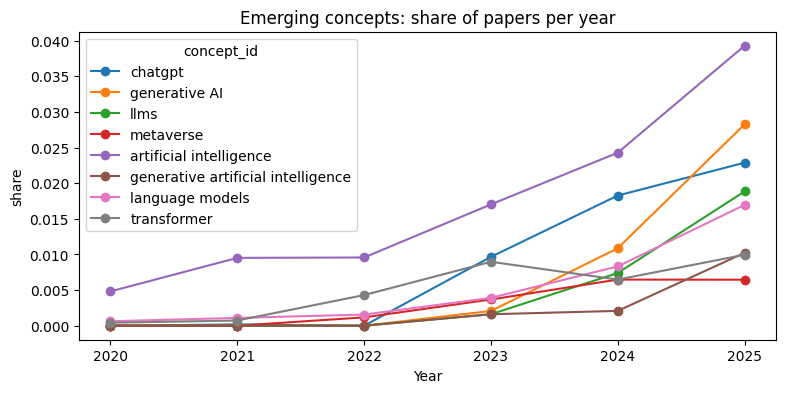

In [39]:
# 4.5 Insights I - overview, productivity, topical trends
display(pd.DataFrame({"nodes": nodes_df.type.value_counts()}).join(pd.DataFrame({"edges": edges_df.rel.value_counts()}), how="outer"))
display(author_master.head(15)[["name", "n_papers", "total_cites", "n_journals", "n_variants"]])
display(df.groupby("Source").agg(papers=("doc_id", "size"), cites=("Cites", "sum")).sort_values("papers", ascending=False).head(10))

pc = doc_concepts.merge(df[["doc_id", "Year"]], on="doc_id")
n_year = df.Year.value_counts()
cy = pc.groupby(["concept_id", "Year"]).doc_id.nunique().unstack(fill_value=0)
share = cy.div(n_year.reindex(cy.columns), axis=1); ys = sorted(cy.columns)

# Re-create mapping dictionary to prevent string override errors
lab_dict = dict(zip(concepts.concept_id, concepts.label))

em = pd.DataFrame({"label": cy.index.map(lab_dict), "papers": cy.sum(1), "early_share": share[ys[:2]].mean(1), "late_share": share[ys[-2:]].mean(1)})
em = em[(em.papers >= 15) & ~em.index.isin(STOP_IDS)]
em["growth"] = (em.late_share + 1e-4) / (em.early_share + 1e-4); em["score"] = np.log(em.growth) * np.sqrt(em.papers)

print("EMERGING concepts (share of papers, last two years vs first two):"); display(em.sort_values("score", ascending=False).head(15))
print("DECLINING concepts:"); display(em.sort_values("score").head(10))

top = em.sort_values("score", ascending=False).head(8).index
share.loc[top].T.rename(columns=lab_dict).plot(marker="o", figsize=(9, 4), title="Emerging concepts: share of papers per year"); plt.ylabel("share"); plt.show()

In [41]:
# 4.6 Insights II - research communities and hidden-link prediction
co = edges_df[edges_df.rel == "CO_OCCURS_WITH"]
Gc = nx.Graph(); Gc.add_weighted_edges_from(zip(co.src, co.dst, co.weight))
comms = sorted(nx.community.louvain_communities(Gc, weight="weight", seed=CFG["SEED"]), key=len, reverse=True)

# Re-create mapping dictionary to prevent string override errors
concept_labels = dict(zip(concepts.concept_id, concepts.label))

rows = []
for k, cset in enumerate(comms[:12]):
    tops = sorted(cset, key=lambda n: -Gc.degree(n, weight="weight"))[:8]
    rows.append(dict(community=k, size=len(cset), top_concepts="; ".join(concept_labels[n] for n in tops)))
print(f"{len(comms)} concept communities (research themes):"); display(pd.DataFrame(rows))

ca = edges_df[edges_df.rel == "CO_AUTHOR_WITH"]
Ga = nx.Graph(); Ga.add_weighted_edges_from(zip(ca.src, ca.dst, ca.weight))
cc_ = sorted(nx.connected_components(Ga), key=len, reverse=True)
print(f"Co-author network: {Ga.number_of_nodes()} authors, {Ga.number_of_edges()} ties, {len(cc_)} components; largest = {len(cc_[0])}")
deg = pd.Series(dict(nx.degree_centrality(Ga))).sort_values(ascending=False).head(10)
display(pd.DataFrame({"author": [node_label[a] for a in deg.index], "degree_centrality": deg.values.round(4)}))

# Hidden relations: pairs that are NOT co-mentioned but share many neighbours (Adamic-Adar) AND are semantically close (embedding cosine)
topn = [n for n, _ in sorted(Gc.degree(), key=lambda x: -x[1])[:600]]; tops_ = set(topn); cands = set()
for u in topn:
    nb = set(Gc[u]); two = set()
    for n in nb:
        if Gc.degree(n) < 500: two |= set(Gc[n])
    cands |= {(u, v) if u < v else (v, u) for v in (two & tops_) - nb - {u}}
cands = list(cands)[:200000]
pred = []
for u, v, aa in nx.adamic_adar_index(Gc, cands):
    cs = float(concept_vec[cid2row[u]] @ concept_vec[cid2row[v]]); pred.append((concept_labels[u], concept_labels[v], round(aa, 2), round(cs, 3), aa * max(cs, 0)))
pred = pd.DataFrame(pred, columns=["concept_a", "concept_b", "adamic_adar", "semantic_cos", "score"]).sort_values("score", ascending=False)
print("Candidate cross-topic links / research gaps:"); display(pred.head(20))

239 concept communities (research themes):


,community,size,top_concepts
0,0,3217,academic libraries; libraries; information lit...
1,1,2159,originality / value; structural equation model...
2,2,2076,Case Study; metadata; digital; knowledge; Info...
3,3,1742,scopus; Web of Science; open access; bibliomet...
4,4,1690,machine learning; Deep Learning; twitter; lear...
5,5,409,Content Analysis; thematic analysis; semi - st...
6,6,316,blockchain; security; framework; cybersecurity...
7,7,230,artificial intelligence; chatgpt; generative A...
8,8,112,quality; National Library; nlm; Overview; Medi...
9,9,40,report; integrated library system; increase im...


Co-author network: 49656 authors, 120904 ties, 7115 components; largest = 21119


,author,degree_centrality
0,Yogesh K. Dwivedi,0.0053
1,Marijn Janssen,0.0040
2,Laurie Hughes,0.0039
3,Ramakrishnan Raman,0.0039
4,Rameshwar Dubey,0.0036
5,Manoj Kumar Tiwari,0.0035
6,Ilias O. Pappas,0.0034
7,Yan Zhang,0.0034
8,Samuel Ribeiro‐Navarrete,0.0034
9,Neeraj Pandey,0.0033


Candidate cross-topic links / research gaps:


,concept_a,concept_b,adamic_adar,semantic_cos,score
12723,academic libraries,public libraries,44.43,0.824,36.617325
109120,librarians,public libraries,40.32,0.710,28.610307
81414,Case Study,machine learning,55.79,0.386,21.530943
119620,Information Science,information literacy,31.74,0.619,19.649410
121265,academic libraries,scopus,53.62,0.350,18.778750
31758,researchers,Case Study,34.89,0.515,17.987454
2932,academic libraries,Web of Science,38.80,0.447,17.327826
45661,information literacy,digital,38.81,0.431,16.714042
145065,library,metadata,46.31,0.353,16.358448
116957,libraries,students,58.83,0.274,16.099462


In [43]:
# 4.7 Information-access tools: semantic search, concept explorer, author profile, similar papers, concept paths
doc_idx = {d: i for i, d in enumerate(df.doc_id)}
concept_labels = dict(zip(concepts.concept_id, concepts.label))
doc_cl = doc_concepts.sort_values("weight", ascending=False).groupby("doc_id").concept_id.apply(lambda x: [concept_labels[c] for c in x][:6]).to_dict()
doc_authors = am.sort_values("pos").groupby("doc_id").author_id.apply(lambda x: "; ".join(node_label[a] for a in x)).to_dict()

def _fmt(idx, scores):
    r = df.iloc[idx][["doc_id", "Title", "Year", "Source", "Cites"]].copy()
    r["score"] = np.round(scores, 3); r["authors"] = r.doc_id.map(doc_authors); r["concepts"] = r.doc_id.map(doc_cl).map(lambda x: ", ".join(x) if isinstance(x, list) else "")
    return r

def search(query, k=10, year_from=None, year_to=None, journal=None, min_cites=0):
    """semantic search over title+abstract embeddings, with metadata filters"""
    q = embedder.encode([query], normalize_embeddings=True)[0]; s = doc_emb @ q
    mask = (df.Cites >= min_cites).to_numpy()
    if year_from: mask = mask & (df.Year >= year_from).to_numpy()
    if year_to:   mask = mask & (df.Year <= year_to).to_numpy()
    if journal:   mask = mask & df.Source.str.contains(journal, case=False).to_numpy()
    idx = np.argsort(-np.where(mask, s, -9))[:k]
    return _fmt(idx, s[idx])

def similar_papers(doc_id, k=10):
    s = doc_emb @ doc_emb[doc_idx[doc_id]]; idx = [i for i in np.argsort(-s)[:k+1] if i != doc_idx[doc_id]][:k]
    return _fmt(idx, s[idx])

def find_concept(q):
    p = SYN.get(norm_phrase(q), norm_phrase(q))
    if p in concept_of: return concept_of[p]
    m = process.extractOne(p, concept_norms, scorer=fuzz.WRatio, score_cutoff=80)
    if m: return concept_of[m[0]]
    return concepts.concept_id.iat[int((concept_vec @ embedder.encode([p], normalize_embeddings=True)[0]).argmax())]

def explore_concept(q, k=10):
    cid = find_concept(q); n = G.nodes[cid]
    print(f"== {n['label']} [{n.get('concept_type')}]  papers={n.get('doc_freq')}  wikidata={n.get('wikidata_id') or '-'}")
    e = edges_df
    nb = e[(e.rel == "CO_OCCURS_WITH") & ((e.src == cid) | (e.dst == cid))].copy()
    nb["other"] = np.where(nb.src == cid, nb.dst, nb.src); nb["concept"] = nb.other.map(node_label)
    print("Most strongly associated concepts (NPMI):"); display(nb.sort_values("npmi", ascending=False)[["concept", "weight", "npmi"]].head(k))
    rl = e[e.rel.isin(REL_TYPES) & (e.src.map(node_type) == "Concept") & ((e.src == cid) | (e.dst == cid))].copy()
    if len(rl):
        rl["from"] = rl.src.map(node_label); rl["to"] = rl.dst.map(node_label)
        print("Extracted relations:"); display(rl.sort_values("weight", ascending=False)[["from", "rel", "to", "weight", "confidence"]].head(k))
    pids = e[(e.rel == "HAS_CONCEPT") & (e.dst == cid)].src
    sub = df[df.doc_id.isin(pids)]
    print("Papers per year:", sub.Year.value_counts().sort_index().to_dict())
    print("Top journals:", sub.Source.value_counts().head(5).to_dict())
    ta = am[am.doc_id.isin(pids)].author_id.value_counts().head(5)
    print("Top authors:", {node_label[a]: int(c) for a, c in ta.items()})
    return sub.sort_values("Cites", ascending=False)[["doc_id", "Title", "Year", "Source", "Cites"]].head(k)

_anames = [norm_phrase(n) for n in author_master.name]
def author_profile(name, k=8):
    m = process.extractOne(norm_phrase(name), _anames, scorer=fuzz.WRatio); a = author_master.iloc[m[2]]
    print(f"== {a['name']} ({a.author_id}) | papers={a.n_papers} cites={a.total_cites} years={a.first_year}-{a.last_year} | name variants: {a.variants[:6]}")
    docs = am[am.author_id == a.author_id].doc_id
    print("Top concepts:", Counter(concept_labels[c] for c in doc_concepts[doc_concepts.doc_id.isin(docs)].concept_id).most_common(k))
    if a.author_id in Ga: print("Top co-authors:", [(node_label[n], Ga[a.author_id][n] ["weight"]) for n in sorted(Ga[a.author_id], key=lambda n: -Ga[a.author_id][n]["weight"])[:k]])
    return df[df.doc_id.isin(docs)].sort_values("Year", ascending=False)[["doc_id", "Title", "Year", "Source", "Cites"]]

def concept_path(a, b):
    ca_, cb_ = find_concept(a), find_concept(b)
    try: return [concept_labels[n] for n in nx.shortest_path(Gc, ca_, cb_)]
    except Exception: return "no path in the co-occurrence graph"

# --- demos (edit the queries)
display(search("large language models for plagiarism detection", k=5, year_from=2023))
display(explore_concept("machine learning", k=8))
print(concept_path("open access", "machine learning"))

,doc_id,Title,Year,Source,Cites,score,authors,concepts
0,P000000,Scholarly Communication and Machine-Generated ...,2023,Journal of Information and Knowledge,18,0.649,Patit Paban Santra; Debasis Majhi,"language models, ai models, AI writing, AI wri..."
6025,P006025,An analysis of large language models: their im...,2024,Knowledge and Information Systems,71,0.566,Mohan Gurusamy; R. Prasanna Kumar; P. Vishal K...,"large, language, analysis, language models, im..."
39,P000039,Text-borrowing Practices in LIS Doctoral These...,2023,Journal of Information and Knowledge,0,0.544,Chikku Balachandran; N. S. Harinarayana,"LIS, Text Copying Practices, Copying Practices..."
10434,P010434,Students’ plagiarism awareness: A study of uni...,2023,Library Herald,0,0.541,Sanjeev Sharma; Manish Kumar,"plagiarism, work, their, research work, contri..."
17767,P017767,"AI Open research Plagiarism Dupli Checker, Scr...",2024,Library Hi Tech News,3,0.538,Dheeraj Singh Negi; Praveen Kumar Pandey,"plagiarism, study, checker, checklist, Compara..."


== machine learning [Method]  papers=892  wikidata=Q6723676
Most strongly associated concepts (NPMI):


,concept,weight,npmi
623407,machine,72.0,0.558
619386,machine learning techniques,39.0,0.523
619210,machine learning algorithms,31.0,0.501
625027,Random Forest,74.0,0.497
608995,machine learning approach,26.0,0.493
625292,machine learning models,19.0,0.472
611618,machine learning methods,18.0,0.461
618603,Svm,69.0,0.452


Extracted relations:


,from,rel,to,weight,confidence
607924,patterns,BASED_ON,machine learning,2.0,0.61
607970,detection,USES,machine learning,2.0,0.61
608111,predictive models,USES,machine learning,2.0,0.61
608154,forecasting,USES,machine learning,2.0,0.61


Papers per year: {2020: 105, 2021: 151, 2022: 185, 2023: 134, 2024: 151, 2025: 166}
Top journals: {'Journal Of Big Data': 189, 'Intelligent systems reference library': 78, 'Webology': 72, 'International Journal of Information Management Data Insights': 47, 'Data Technologies and Applications': 39}
Top authors: {'Taghi M. Khoshgoftaar': 17, 'Joffrey L. Leevy': 10, 'Borko Furht': 5, 'John Hancock': 5, 'Parthasarathi Mukhopadhyay': 5}


,doc_id,Title,Year,Source,Cites
5015,P005015,Selecting critical features for data classific...,2020,Journal Of Big Data,938
5016,P005016,A survey on missing data in machine learning,2021,Journal Of Big Data,896
9417,P009417,ChatGPT and a new academic reality:Artificial ...,2023,Journal of the Association for Information Sci...,712
5018,P005018,Cybersecurity data science: an overview from m...,2020,Journal Of Big Data,683
24297,P024297,Explainable AI (XAI): A systematic meta-survey...,2023,Knowledge-Based Systems,631
23758,P023758,Fake news detection: A hybrid CNN-RNN based de...,2021,International Journal of Information Managemen...,544
5021,P005021,Performance Analysis of Intrusion Detection Sy...,2020,Journal Of Big Data,503
6012,P006012,Feature selection techniques for machine learn...,2023,Knowledge and Information Systems,356


['open access', 'metadata', 'machine learning']


In [45]:
# 4.8 Interactive graph of a concept neighbourhood (pyvis)
from pyvis.network import Network
COL = {"Concept": "#4C78A8", "Technology": "#F58518", "Method": "#54A24B", "Task": "#E45756", "LIS_Practice": "#72B7B2", "Data_Resource": "#B279A2", "Domain_Topic": "#9D755D"}
def show_concept_graph(q, max_nodes=35, fname="concept_graph.html"):
    cid = find_concept(q)
    nb = co[(co.src == cid) | (co.dst == cid)].copy(); nb["other"] = np.where(nb.src == cid, nb.dst, nb.src)
    keep = list(nb.sort_values("npmi", ascending=False).other.head(max_nodes))
    rel_ = edges_df[edges_df.rel.isin(REL_TYPES) & (edges_df.src.map(node_type) == "Concept") & ((edges_df.src == cid) | (edges_df.dst == cid))]
    net = Network(height="650px", width="100%", cdn_resources="in_line", bgcolor="#ffffff", font_color="#222")
    ct = dict(zip(concepts.concept_id, concepts.concept_type))
    local_concept_labels = dict(zip(concepts.concept_id, concepts.label))
    for n in [cid] + keep + [x for x in set(rel_.src) | set(rel_.dst) if x not in keep and x != cid]:
        net.add_node(n, label=local_concept_labels[n], title=f"{local_concept_labels[n]} ({ct[n]}), papers={dfreq[n]}", size=12 + 6*math.log1p(dfreq[n]), color=COL.get(ct[n], "#999"), borderWidth=3 if n == cid else 1)
    ids_ = {n["id"] for n in net.nodes}
    for r in nb[nb.other.isin(keep)].itertuples(): net.add_edge(cid, r.other, value=float(r.npmi), title=f"co-occurs (NPMI {r.npmi})", color="#cccccc")
    for r in rel_.itertuples():
        if r.src in ids_ and r.dst in ids_: net.add_edge(r.src, r.dst, label=r.rel, arrows="to", color="#E45756", title=str(r.evidence)[:200])
    path = os.path.join(OUT, fname); net.write_html(path); display(HTML(open(path).read()))
show_concept_graph("knowledge graph")

In [46]:
# 4.9 Export: CSV, GraphML (Gephi/Cytoscape), RDF N-Triples (+ small SPARQL demo), Neo4j-ready CSV
nodes_df.to_csv(f"{OUT}/kg_nodes.csv", index=False); edges_df.to_csv(f"{OUT}/kg_edges.csv", index=False)
author_master.assign(variants=author_master.variants.map("; ".join)).to_csv(f"{OUT}/author_master.csv", index=False)
concepts.assign(members=concepts.members.map("; ".join)).to_csv(f"{OUT}/concepts.csv", index=False)
validation_report.to_csv(f"{OUT}/validation_report.csv", index=False)

EXPORT_GRAPHML = True                         # large for the full corpus (hundreds of MB); set False to skip
if EXPORT_GRAPHML: nx.write_graphml(G, f"{OUT}/kg.graphml")

BASE = "http://example.org/lis-kg/"
lit = lambda s: '"' + str(s).replace("\\", "\\\\").replace('"', '\\"').replace("\n", " ") + '"'
with open(f"{OUT}/kg.nt", "w", encoding="utf-8") as f:
    T, L, SA = "http://www.w3.org/1999/02/22-rdf-syntax-ns#type", "http://www.w3.org/2000/01/rdf-schema#label", "http://www.w3.org/2002/07/owl#sameAs"
    for r in nodes_df.itertuples():
        f.write(f"<{BASE}{r.node_id}> <{T}> <{BASE}{r.type}> .\n<{BASE}{r.node_id}> <{L}> {lit(r.label)} .\n")
        if isinstance(getattr(r, "wikidata_id", None), str) and r.wikidata_id: f.write(f"<{BASE}{r.node_id}> <{SA}> <http://www.wikidata.org/entity/{r.wikidata_id}> .\n")
    for e in edges_df.itertuples(): f.write(f"<{BASE}{e.src}> <{BASE}rel/{e.rel}> <{BASE}{e.dst}> .\n")

nodes_df.rename(columns={"node_id": "node_id:ID", "type": ":LABEL"}).to_csv(f"{OUT}/neo4j_nodes.csv", index=False)
edges_df.rename(columns={"src": ":START_ID", "dst": ":END_ID", "rel": ":TYPE"}).to_csv(f"{OUT}/neo4j_relationships.csv", index=False)

# --- SPARQL demo on a small slice (first 1000 papers)
import rdflib
from rdflib import Namespace, Literal, RDF, RDFS
KG, KR = Namespace(BASE), Namespace(BASE + "rel/")
sub_e = edges_df[edges_df.src.isin(set(df.doc_id.head(1000))) & edges_df.rel.isin(["AUTHORED_BY", "HAS_CONCEPT", "PUBLISHED_IN", "PUBLISHED_IN_YEAR"])]
keep = set(sub_e.src) | set(sub_e.dst); rg = rdflib.Graph()
for r in nodes_df[nodes_df.node_id.isin(keep)].itertuples(): rg.add((KG[r.node_id], RDF.type, KG[r.type])); rg.add((KG[r.node_id], RDFS.label, Literal(r.label)))
for e in sub_e.itertuples(): rg.add((KG[e.src], KR[e.rel], KG[e.dst]))
q = """PREFIX rel: <http://example.org/lis-kg/rel/> PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?title ?author WHERE { ?p rel:HAS_CONCEPT ?c . ?c rdfs:label ?cl . ?p rdfs:label ?title . ?p rel:AUTHORED_BY ?a . ?a rdfs:label ?author .
 FILTER(CONTAINS(LCASE(STR(?cl)), "open access")) } LIMIT 10"""
display(pd.DataFrame([(str(a), str(b)) for a, b in rg.query(q)], columns=["title", "author"]))
print("Saved to", OUT); print(sorted(os.listdir(OUT)))
# from google.colab import files; !zip -rq /content/kg_output.zip /content/kg_output; files.download("/content/kg_output.zip")

,title,author
0,Analysing Library and Information Science Arti...,Debasis Majhi
1,Unveiling Gender Discrepancy in Open Access LI...,Manoj Kumar Verma
2,Measuring the Acceptance of Open Access Schola...,Manoj Kumar Verma
3,Measuring the Acceptance of Open Access Schola...,Manoj Kumar Verma
4,Open Access Availability of Indias Scientific ...,Manoj Kumar Verma
5,Open Access Mandates and Policies Adopted by t...,Manoj Kumar Verma
6,Open Access Mandates and Policies Adopted by t...,Manoj Kumar Verma
7,Exploring the Impact of Social Networking Site...,Manoj Kumar Verma
8,Exploring the Impact of Social Networking Site...,Mayank Yuvaraj
9,Measuring Alternative Research Impact of Priva...,Amit Nath


Saved to /content/kg_output
['author_master.csv', 'concept_graph.html', 'concepts.csv', 'doc_emb_27749.npy', 'docs_27749.spacy', 'kg.graphml', 'kg.nt', 'kg_edges.csv', 'kg_nodes.csv', 'neo4j_nodes.csv', 'neo4j_relationships.csv', 'ner_chunks_27749.pkl', 'openalex_cache.json', 'phrase_emb_75345.npy', 'validation_audit.xlsx', 'validation_report.csv', 'wikidata_cache.json']


In [47]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

## Notes: tuning, validation and limits
* **Rough time estimates (27.8k papers, T4 GPU; not benchmarked):** embeddings ≈ 3 min, spaCy pass ≈ 8–12 min, phrase embeddings + concept clustering ≈ 5 min, author step ≈ 2–4 min, relation extraction ≈ 5 min. Everything expensive is cached in `OUT_DIR`, so a crash/restart resumes quickly.
* **What is machine-learned vs rule-based:** document/phrase embeddings, MMR keyphrases, topic clusters, concept merging, concept typing and Wikidata disambiguation are embedding-based; NER is spaCy + a LIS gazetteer; relations are dependency rules over a verb lexicon (high precision, modest recall).
* **No ground truth ships with the dataset.** Author-merge thresholds (`T_*`), concept-merge thresholds and `MIN_REL_SUPPORT` are sensible defaults, not tuned values. Label the audit workbook from 4.4, run `evaluate_audit()`, adjust `CFG`, re-run Parts 2–4.
* **Authors:** the file has no affiliations/ORCIDs, so identical full names (e.g. "Wei Zhang") cannot be split reliably. They are flagged by `homonym_risk`; the optional OpenAlex step (2.7) is the strongest fix. Names are assumed *Given … Surname* order, with an inversion pass for Chinese/South-Asian orderings.
* **Corpus scope:** the 100 journals include many computer-science and information-systems titles, not only core LIS; topics (1.7) will reflect that. Filter `df` by `Source` after 1.2 if you want a pure-LIS graph.
* **Relations come mostly from abstracts**; ~38 % of rows have no real abstract (only title), so those papers get metadata, keyword and keyphrase edges but few extracted relations.